<a href="https://colab.research.google.com/github/kanokwantho/Project_Tonper/blob/main/quarter3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_excel('opendata_02_service_ip_66q3.xlsx')

print("ขนาดข้อมูล:", df.shape)
df.head()

ขนาดข้อมูล: (490971, 12)


,month_no,hcode,hname,province_id,prov,nhso_zonename,gender,service_type,pdx,pdx_name,n_pop,n_service
0,202304,4007,รพ.ซับใหญ่,3600,ชัยภูมิ,เขต 9 นครราชสีมา,1,IP,I61,Intracerebral haemorrhage,1,1
1,202304,4007,รพ.ซับใหญ่,3600,ชัยภูมิ,เขต 9 นครราชสีมา,2,IP,K56,Paralytic ileus and intestinal obstruction wit...,1,1
2,202304,4007,รพ.ซับใหญ่,3600,ชัยภูมิ,เขต 9 นครราชสีมา,2,IP,R56,Convulsions not elsewhere classified,1,1
3,202304,4007,รพ.ซับใหญ่,3600,ชัยภูมิ,เขต 9 นครราชสีมา,2,IP,J02,Acute pharyngitis,1,1
4,202304,4007,รพ.ซับใหญ่,3600,ชัยภูมิ,เขต 9 นครราชสีมา,2,IP,A09,Diarrhoea and gastroenteritis of presumed infe...,3,3


In [4]:
df["month_no"] = df["month_no"].astype(str)

df["date"] = pd.to_datetime(
    df["month_no"],
    format="%Y%m",
    errors="coerce"
)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df[["month_no", "date", "year", "month"]].head()

,month_no,date,year,month
0,202304,2023-04-01,2023,4
1,202304,2023-04-01,2023,4
2,202304,2023-04-01,2023,4
3,202304,2023-04-01,2023,4
4,202304,2023-04-01,2023,4


##**Clean ข้อมูล**

In [5]:
text_cols = [
    'hname',
    'prov',
    'nhso_zonename',
    'service_type',
    'pdx',
    'pdx_name'
]

for col in text_cols:
    df[col] = df[col].astype('string').str.strip()
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

In [6]:
# ตรวจ Missing Value
print(df.isna().sum())

month_no            0
hcode               0
hname               0
province_id         0
prov                0
nhso_zonename       0
gender              0
service_type        0
pdx                 0
pdx_name         1219
n_pop               0
n_service           0
date                0
year                0
month               0
dtype: int64


##**แยกภูมิภาค**

In [24]:
df['prov'] = (
    df['prov']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)


# 2. Mapping จังหวัด -> ภาค
region_mapping = {
    'เหนือ': [
        'เชียงใหม่', 'เชียงราย', 'ลำปาง', 'ลำพูน', 'แม่ฮ่องสอน',
        'น่าน', 'พะเยา', 'แพร่', 'อุตรดิตถ์'
    ],

    'ตะวันออกเฉียงเหนือ': [
        'กาฬสินธุ์', 'ขอนแก่น', 'ชัยภูมิ', 'นครพนม', 'นครราชสีมา',
        'บึงกาฬ', 'บุรีรัมย์', 'มหาสารคาม', 'มุกดาหาร', 'ยโสธร',
        'ร้อยเอ็ด', 'เลย', 'ศรีสะเกษ', 'สกลนคร', 'สุรินทร์',
        'หนองคาย', 'หนองบัวลำภู', 'อุดรธานี', 'อุบลราชธานี',
        'อำนาจเจริญ'
    ],

    'กลาง': [
        'กรุงเทพฯ', 'กำแพงเพชร', 'ชัยนาท', 'นครนายก', 'นครปฐม',
        'นครสวรรค์', 'นนทบุรี', 'ปทุมธานี', 'พระนครศรีอยุธยา',
        'พิจิตร', 'พิษณุโลก', 'เพชรบูรณ์', 'ลพบุรี', 'สมุทรปราการ',
        'สมุทรสงคราม', 'สมุทรสาคร', 'สระบุรี', 'สิงห์บุรี',
        'สุโขทัย', 'สุพรรณบุรี', 'อ่างทอง', 'อุทัยธานี'
    ],

    'ตะวันตก': [
        'กาญจนบุรี', 'ตาก', 'ประจวบคีรีขันธ์', 'เพชรบุรี', 'ราชบุรี'
    ],

    'ตะวันออก': [
        'จันทบุรี', 'ฉะเชิงเทรา', 'ชลบุรี', 'ตราด',
        'ปราจีนบุรี', 'ระยอง', 'สระแก้ว'
    ],

    'ใต้': [
        'กระบี่', 'ชุมพร', 'ตรัง', 'นครศรีธรรมราช', 'นราธิวาส',
        'ปัตตานี', 'พังงา', 'พัทลุง', 'ภูเก็ต', 'ยะลา',
        'ระนอง', 'สตูล', 'สงขลา', 'สุราษฎร์ธานี'
    ]
}


# 3. สร้าง dictionary จังหวัด -> ภาค
province_to_region = {}

for region, provinces in region_mapping.items():
    for province in provinces:
        province_to_region[province] = region


# 4. แยกภาค
# ถ้าเป็นจังหวัด -> แสดงชื่อภาค
# ถ้าไม่ใช่จังหวัดใน mapping -> แสดงชื่อเดิมของ prov
df['ภาค'] = df['prov'].map(province_to_region)

df['ภาค'] = df['ภาค'].fillna(df['prov'])


# 5. แสดงผลทั้งหมด
display(
    df[['prov', 'ภาค']]
    .drop_duplicates()
    .sort_values(['ภาค', 'prov'])
)

,prov,ภาค
158236,กรมแพทย์ทหารอากาศ,กรมแพทย์ทหารอากาศ
158223,กรมแพทย์ทหารเรือ,กรมแพทย์ทหารเรือ
134435,กรุงเทพฯ,กลาง
32584,กำแพงเพชร,กลาง
19696,ชัยนาท,กลาง
...,...,...
15922,ยะลา,ใต้
40892,ระนอง,ใต้
14650,สงขลา,ใต้
42123,สตูล,ใต้


In [25]:
# ตรวจสอบข้อมูลที่ยังไม่ได้อยู่ในภูมิภาค
missing_region = df[df['ภาค'].isna()]

print("จำนวนข้อมูลที่ยังไม่มีภูมิภาค:", len(missing_region))

if len(missing_region) > 0:
    print("\n===== รายการที่ยังไม่มีภูมิภาค =====")
    display(
        missing_region[
            ['prov', 'hname', 'hcode', 'ภาค']
        ]
        .drop_duplicates()
        .sort_values(['prov', 'hname'])
    )
else:
    print("✅ ข้อมูลทั้งหมดถูกจัดอยู่ในภูมิภาคเรียบร้อยแล้ว")

จำนวนข้อมูลที่ยังไม่มีภูมิภาค: 0
✅ ข้อมูลทั้งหมดถูกจัดอยู่ในภูมิภาคเรียบร้อยแล้ว


In [29]:
# ทำสำเนาไว้สำหรับวิเคราะห์
data = df.copy()

# ลบช่องว่างในข้อมูลข้อความ
text_cols = ["prov", "ภาค", "nhso_zonename", "pdx_name"]

for col in text_cols:
    data[col] = data[col].astype(str).str.strip()

# แปลงจำนวนบริการเป็นตัวเลข
data["n_service"] = pd.to_numeric(data["n_service"], errors="coerce")

# แปลงประชากรเป็นตัวเลข
data["n_pop"] = pd.to_numeric(data["n_pop"], errors="coerce")

# ลบข้อมูลที่ไม่มีค่าที่จำเป็น
data = data.dropna(
    subset=["prov", "ภาค", "pdx_name", "n_service"]
)

print("จำนวนข้อมูล:", len(data))
print("จำนวนภาค:", data["ภาค"].nunique())
print("จำนวนจังหวัด:", data["prov"].nunique())
print("จำนวนโรค:", data["pdx_name"].nunique())

จำนวนข้อมูล: 490971
จำนวนภาค: 8
จำนวนจังหวัด: 79
จำนวนโรค: 1446


##**จำนวนครั้งเข้ารับบริการ จำแนกตามภาค**

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


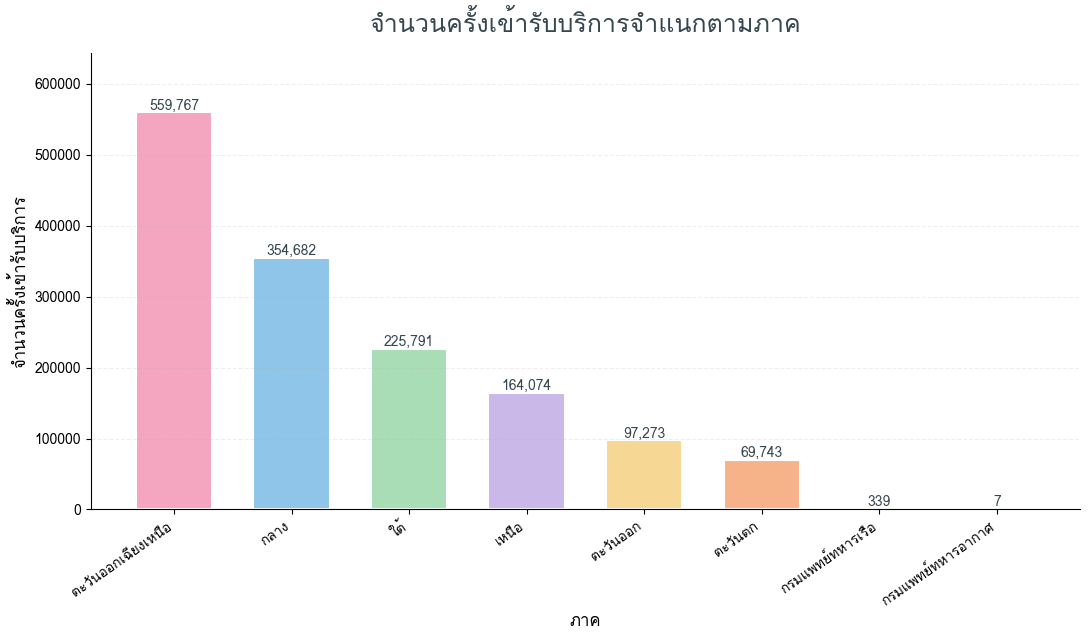

In [103]:
!apt-get install -y --no-install-recommends fonts-thai-tlwg

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.font_manager.fontManager.addfont(
    '/usr/share/fonts/truetype/tlwg/Loma.ttf'
)
mpl.rc('font', family='Loma')

# รวมจำนวนบริการตามภาค
region_service = (
    df.groupby("ภาค")["n_service"]
      .sum()
      .sort_values(ascending=False)
)

# สีพาสเทลน่ารัก
cute_colors = [
    "#F4A6C1",  # ชมพู
    "#8EC5E8",  # ฟ้า
    "#A8DDB5",  # เขียว
    "#C9B8E8",  # ม่วง
    "#F7D794",  # เหลือง
    "#F6B38A",  # ส้ม
    "#D8A7C7",  # ชมพูม่วง
    "#A8C8E8"   # ฟ้าอ่อน
]

# สร้างกราฟ
fig, ax = plt.subplots(figsize=(11, 6.5))

bars = ax.bar(
    region_service.index,
    region_service.values,
    color=cute_colors[:len(region_service)],
    edgecolor="white",
    linewidth=1.5,
    width=0.65
)

# ชื่อกราฟ
ax.set_title(
    "จำนวนครั้งเข้ารับบริการจำแนกตามภาค",
    fontsize=18,
    fontweight="bold",
    color="#37474F",
    pad=15
)

ax.set_xlabel(
    "ภาค",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "จำนวนครั้งเข้ารับบริการ",
    fontsize=12,
    fontweight="bold"
)

# หมุนชื่อภาค
plt.xticks(
    rotation=35,
    ha="right",
    fontsize=10
)

# ใส่ตัวเลขบนแท่งกราฟ
for bar, value in zip(bars, region_service.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight="bold",
        color="#37474F"
    )

# Grid เบา ๆ
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

# เอากรอบด้านบนและขวาออก
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# เพิ่มพื้นที่ด้านบนสำหรับตัวเลข
ax.set_ylim(
    0,
    region_service.max() * 1.15
)

plt.tight_layout()
plt.show()

##**Top 5 โรคที่มีจำนวนครั้งเข้ารับบริการสูงสุด จำแนกตามภูมิภาค**

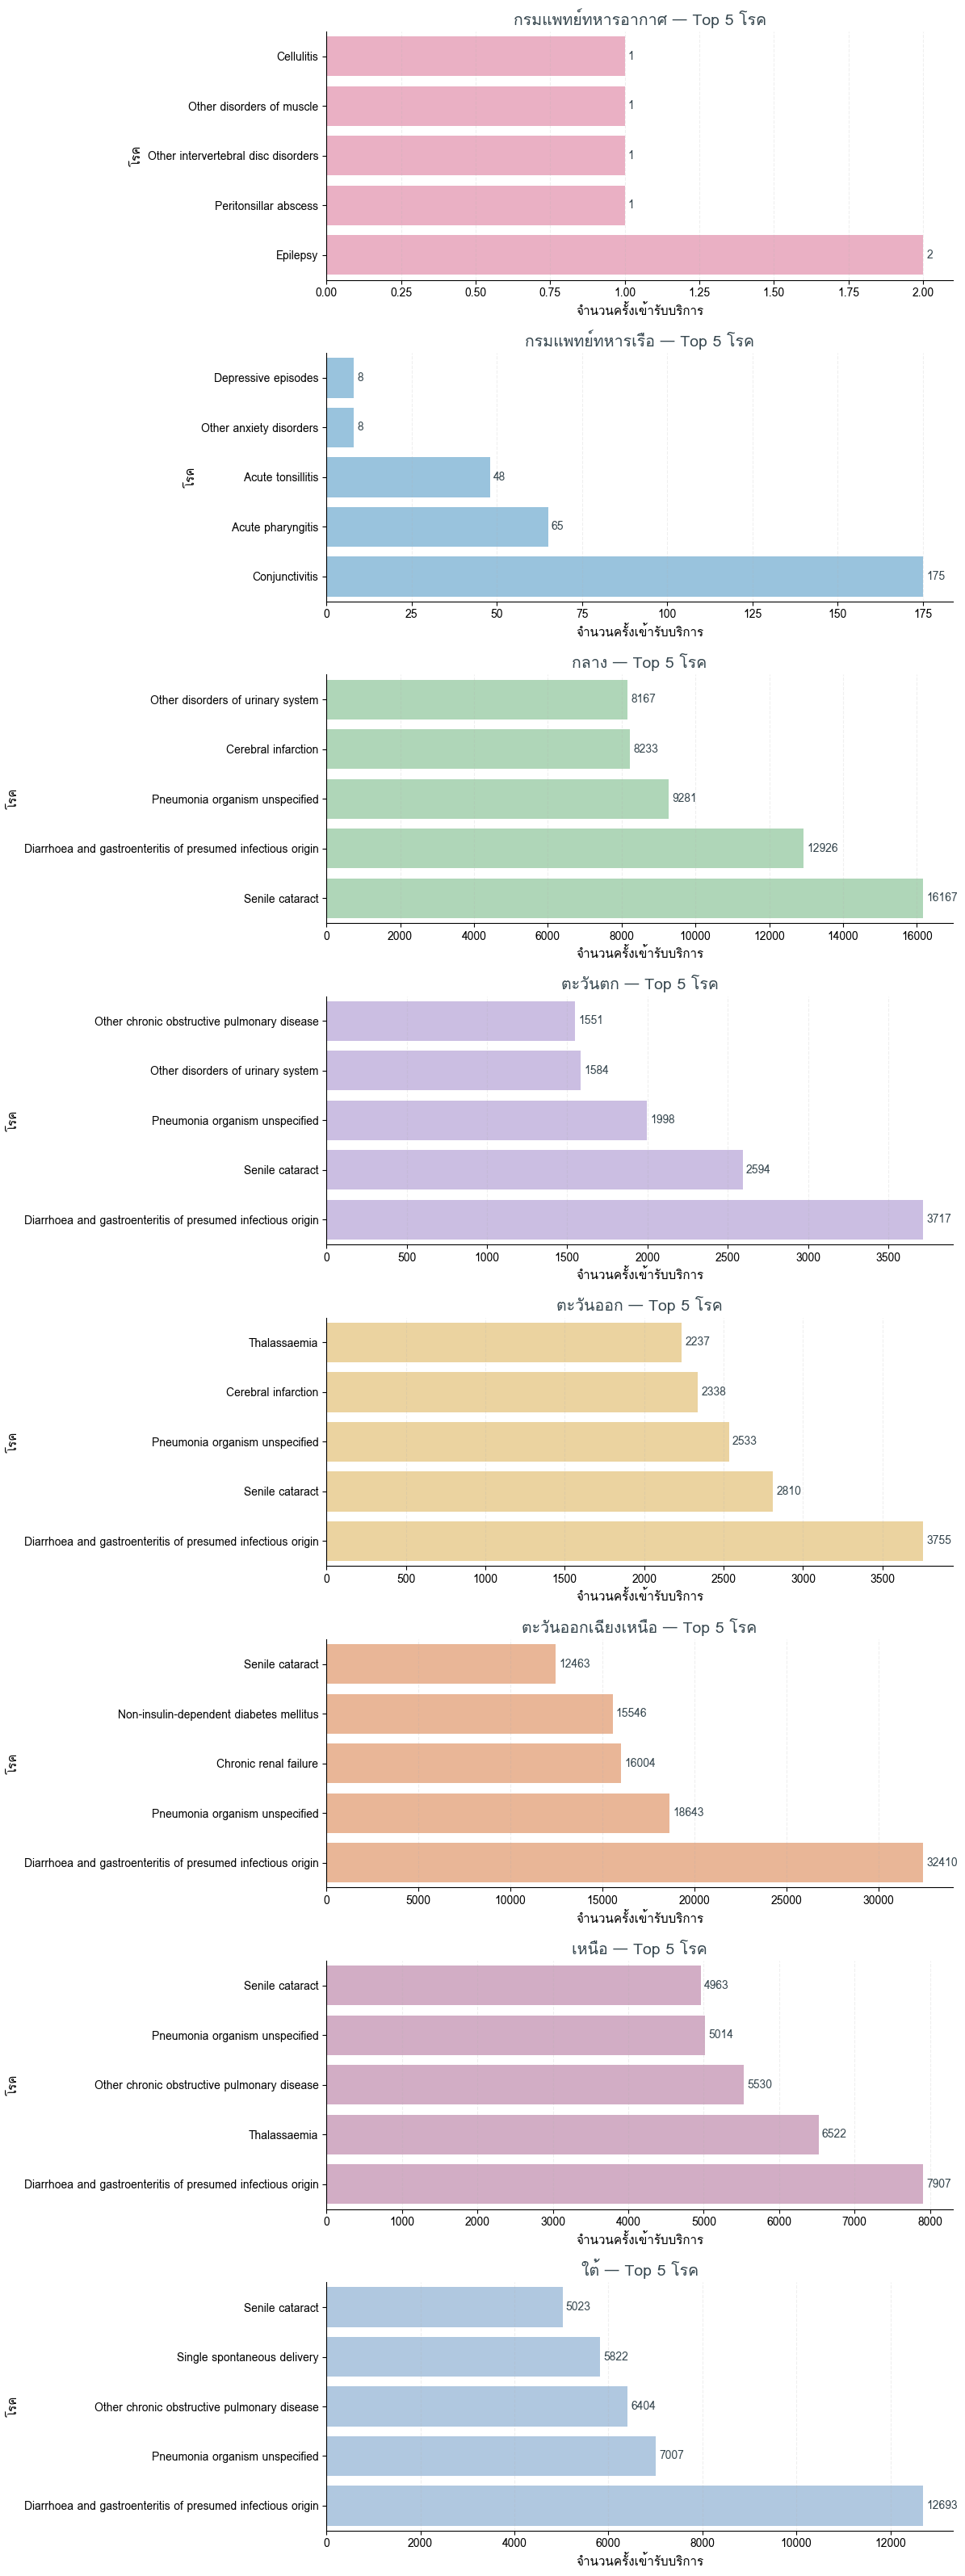

In [102]:
# Top 5 โรคที่มีจำนวนครั้งเข้ารับบริการสูงสุด จำแนกตามภูมิภาค

import matplotlib.pyplot as plt
import seaborn as sns

# รวมจำนวนบริการ
region_disease = (
    data.groupby(["ภาค", "pdx_name"])["n_service"]
    .sum()
    .reset_index()
)

# เตรียมภาคทั้งหมด
regions = region_disease["ภาค"].dropna().unique()

# สีพาสเทลน่ารัก
pastel_colors = [
    "#F4A6C1",  # ชมพู
    "#8EC5E8",  # ฟ้า
    "#A8DDB5",  # เขียว
    "#C9B8E8",  # ม่วง
    "#F7D794",  # เหลือง
    "#F6B38A",  # ส้ม
    "#D8A7C7",  # ชมพูม่วง
    "#A8C8E8"   # ฟ้าอ่อน
]

# สร้างกราฟ
fig, axes = plt.subplots(
    nrows=len(regions),
    ncols=1,
    figsize=(12, 4 * len(regions))
)

# กรณีมีแค่ 1 ภาค
if len(regions) == 1:
    axes = [axes]

for i, (ax, region) in enumerate(zip(axes, regions)):

    # เลือกข้อมูลของภาคนั้น
    temp = region_disease[
        region_disease["ภาค"] == region
    ].sort_values(
        "n_service",
        ascending=True
    ).tail(5)

    # ใช้สีเดียวกันทั้ง 5 โรค
    sns.barplot(
        data=temp,
        x="n_service",
        y="pdx_name",
        ax=ax,
        color=pastel_colors[i % len(pastel_colors)]
    )

    # ชื่อกราฟ
    ax.set_title(
        f"{region} — Top 5 โรค",
        fontsize=14,
        fontweight="bold",
        color="#37474F"
    )

    ax.set_xlabel(
        "จำนวนครั้งเข้ารับบริการ",
        fontsize=11
    )

    ax.set_ylabel(
        "โรค",
        fontsize=11
    )

    # ใส่จำนวนปลายแท่ง
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f",
            padding=3,
            fontsize=10,
            fontweight="bold",
            color="#37474F"
        )

    # Grid เบา ๆ
    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.2
    )

    # เอากรอบบนและขวาออก
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

##**สัดส่วนเพศของผู้เข้ารับบริการใน 5 โรคหลัก**


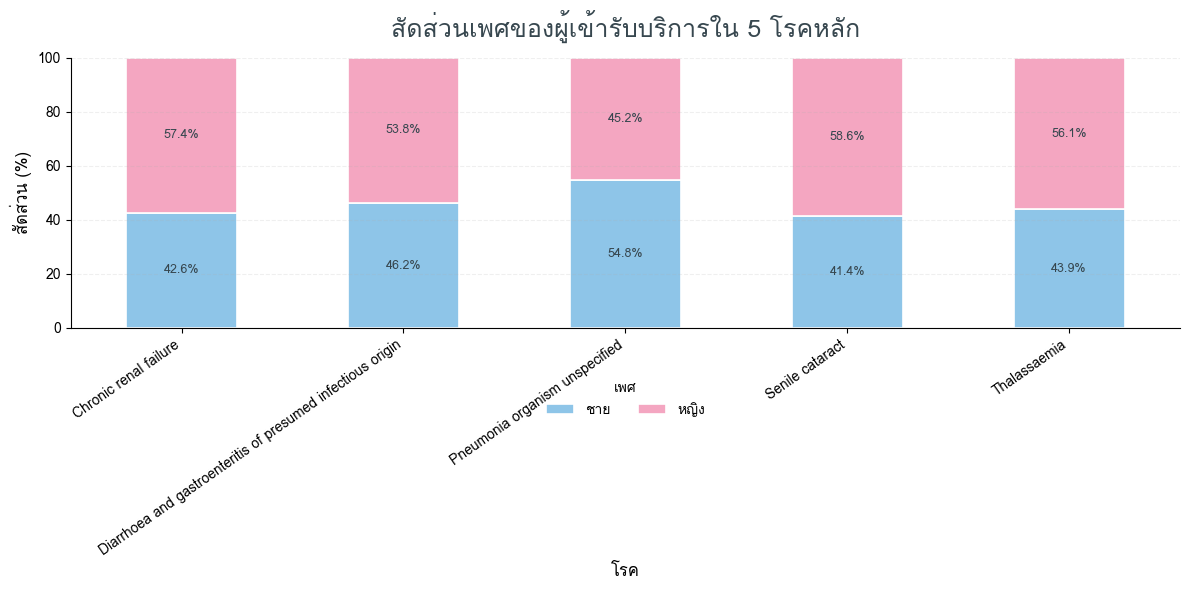

In [100]:
# สัดส่วนเพศของผู้เข้ารับบริการใน 5 โรคหลัก

import matplotlib.pyplot as plt
import pandas as pd

# แปลงรหัสเพศ
data["gender_label"] = data["gender"].map({
    1: "ชาย",
    2: "หญิง"
}).fillna("ไม่ระบุ")

# หา Top 5 โรคที่มีจำนวนครั้งเข้ารับบริการสูงสุด
top5_disease = (
    data.groupby("pdx_name")["n_service"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# รวมจำนวนบริการตามโรคและเพศ
gender_disease = (
    data[data["pdx_name"].isin(top5_disease)]
    .groupby(["pdx_name", "gender_label"])["n_service"]
    .sum()
    .unstack(fill_value=0)
)

# เปลี่ยนเป็นเปอร์เซ็นต์
gender_pct = (
    gender_disease.div(gender_disease.sum(axis=1), axis=0) * 100
)

# -----------------------------
# สีพาสเทลน่ารัก
# -----------------------------
colors = {
    "ชาย": "#8EC5E8",       # ฟ้าพาสเทล
    "หญิง": "#F4A6C1",      # ชมพูพาสเทล
    "ไม่ระบุ": "#C9B8E8"    # ม่วงพาสเทล
}

# เรียงคอลัมน์ให้เป็น ชาย → หญิง → ไม่ระบุ
gender_order = ["ชาย", "หญิง", "ไม่ระบุ"]
gender_pct = gender_pct.reindex(
    columns=[x for x in gender_order if x in gender_pct.columns]
)

# -----------------------------
# วาดกราฟ
# -----------------------------
ax = gender_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=[
        colors[col]
        for col in gender_pct.columns
    ],
    edgecolor="white",
    linewidth=1.2
)

# Title
plt.title(
    "สัดส่วนเพศของผู้เข้ารับบริการใน 5 โรคหลัก",
    fontsize=18,
    fontweight="bold",
    color="#37474F",
    pad=15
)

plt.xlabel(
    "โรค",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "สัดส่วน (%)",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=35,
    ha="right",
    fontsize=10
)

plt.yticks(fontsize=10)
plt.ylim(0, 100)

# เส้น Grid เบา ๆ
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

# -----------------------------
# ใส่เปอร์เซ็นต์บนแท่ง
# -----------------------------
for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() >= 5
        else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        fontweight="bold",
        color="#37474F"
    )

# Legend ด้านล่างตรงกลาง
plt.legend(
    title="เพศ",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False
)

# ลบกรอบด้านบนและขวา
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

##**จำนวนครั้งเข้ารับบริการจำแนกตามเขตสุขภาพ**

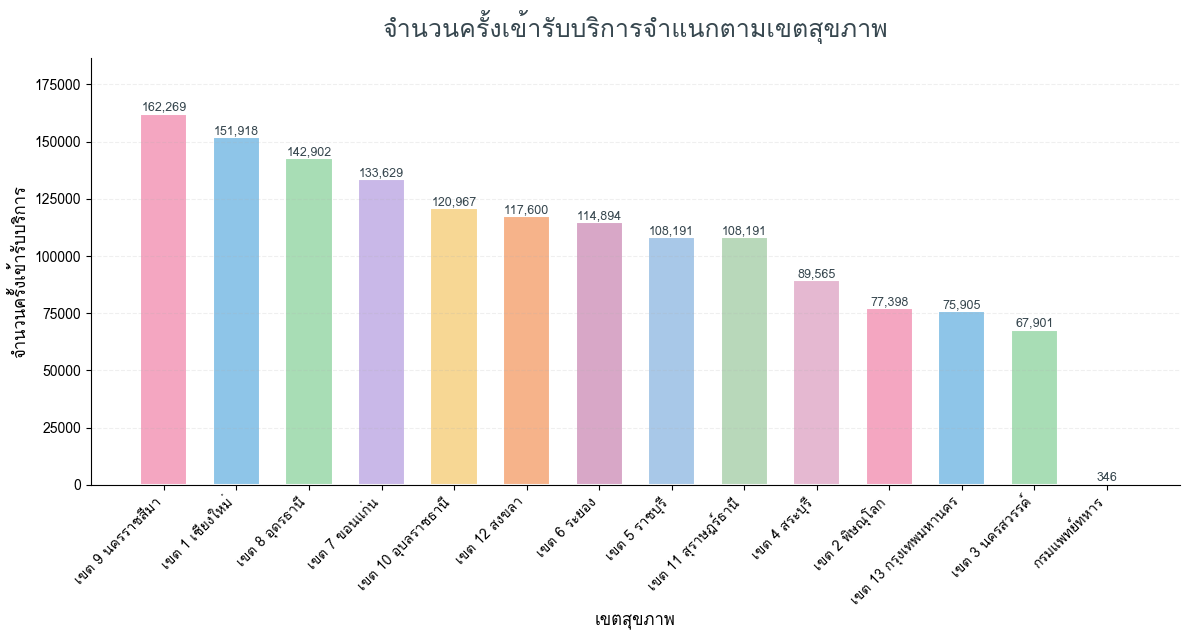

In [104]:
# จำนวนครั้งเข้ารับบริการจำแนกตามเขตสุขภาพ

import matplotlib.pyplot as plt
import matplotlib as mpl

# รวมจำนวนบริการ
zone_service = (
    data.groupby("nhso_zonename")["n_service"]
    .sum()
    .sort_values(ascending=False)
)

# สีพาสเทลน่ารัก
cute_colors = [
    "#F4A6C1",  # ชมพู
    "#8EC5E8",  # ฟ้า
    "#A8DDB5",  # เขียว
    "#C9B8E8",  # ม่วง
    "#F7D794",  # เหลือง
    "#F6B38A",  # ส้ม
    "#D8A7C7",  # ชมพูม่วง
    "#A8C8E8",  # ฟ้าอ่อน
    "#B8D8BA",  # เขียวอ่อน
    "#E5B8D1"   # ชมพูอ่อน
]

# สร้างกราฟ
fig, ax = plt.subplots(figsize=(12, 6.5))

bars = ax.bar(
    zone_service.index,
    zone_service.values,
    color=cute_colors[:len(zone_service)],
    edgecolor="white",
    linewidth=1.5,
    width=0.65
)

# ชื่อกราฟ
ax.set_title(
    "จำนวนครั้งเข้ารับบริการจำแนกตามเขตสุขภาพ",
    fontsize=18,
    fontweight="bold",
    color="#37474F",
    pad=15
)

ax.set_xlabel(
    "เขตสุขภาพ",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "จำนวนครั้งเข้ารับบริการ",
    fontsize=12,
    fontweight="bold"
)

# หมุนชื่อเขตสุขภาพ
plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10
)

# ใส่ตัวเลขบนแท่ง
for bar, value in zip(bars, zone_service.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#37474F"
    )

# Grid เบา ๆ
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

# ลบกรอบด้านบนและขวา
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# เพิ่มพื้นที่ด้านบนสำหรับตัวเลข
ax.set_ylim(
    0,
    zone_service.max() * 1.15
)

plt.tight_layout()
plt.show()

In [39]:
print("จำนวนเขตสุขภาพทั้งหมด:",
      data[data["nhso_zonename"].str.startswith("เขต", na=False)]["nhso_zonename"].nunique())

print(
    sorted(
        data[data["nhso_zonename"].str.startswith("เขต", na=False)]["nhso_zonename"]
        .unique()
    )
)

จำนวนเขตสุขภาพทั้งหมด: 13
['เขต 1 เชียงใหม่', 'เขต 10 อุบลราชธานี', 'เขต 11 สุราษฎร์ธานี', 'เขต 12 สงขลา', 'เขต 13 กรุงเทพมหานคร', 'เขต 2 พิษณุโลก', 'เขต 3 นครสวรรค์', 'เขต 4 สระบุรี', 'เขต 5 ราชบุรี', 'เขต 6 ระยอง', 'เขต 7 ขอนแก่น', 'เขต 8 อุดรธานี', 'เขต 9 นครราชสีมา']


##**จำนวนครั้งเข้ารับบริการจำแนกตามภาคและจังหวัด**

In [99]:
import plotly.express as px

# รวมจำนวนครั้งเข้ารับบริการตามภาคและจังหวัด
province_service = (
    data.groupby(["ภาค", "prov"])["n_service"]
    .sum()
    .reset_index()
)

# เรียงจากมากไปน้อย
province_service = province_service.sort_values(
    "n_service",
    ascending=False
)

# สีแยกตามภูมิภาค
region_colors = {
    "เหนือ": "#F4A6C1",                  # ชมพู
    "ตะวันออกเฉียงเหนือ": "#8EC5E8",    # ฟ้า
    "กลาง": "#A8DDB5",                   # เขียว
    "ตะวันตก": "#F6B38A",               # ส้ม
    "ตะวันออก": "#F7D794",              # เหลือง
    "ใต้": "#C9B8E8",                    # ม่วง
    "กรมแพทย์ทหารอากาศ": "#D8A7CA",     # ชมพูม่วง
    "กรมแพทย์ทหารเรือ": "#A9C7E8"       # ฟ้าอมม่วง
}

# สร้าง Treemap
fig = px.treemap(
    province_service,
    path=["ภาค", "prov"],
    values="n_service",
    color="ภาค",
    color_discrete_map=region_colors,
    title="จำนวนครั้งเข้ารับบริการจำแนกตามจังหวัดและภูมิภาค"
)

# แสดงชื่อ + จำนวนครั้ง
fig.update_traces(
    textinfo="label+value",
    texttemplate="%{label}<br>%{value:,.0f}",
    textfont=dict(
        size=14,
        color="#263238"
    ),
    marker=dict(
        line=dict(
            color="white",
            width=2
        )
    )
)

# ปรับ Layout
fig.update_layout(
    width=1100,
    height=700,
    title=dict(
        font=dict(
            size=22,
            color="#37474F"
        ),
        x=0.5
    ),
    margin=dict(
        t=80,
        l=20,
        r=20,
        b=20
    ),
    paper_bgcolor="white",
    plot_bgcolor="white"
)

fig.show()

##**สัดส่วนผู้เข้ารับบริการจำแนกตามเพศและภูมิภาค**

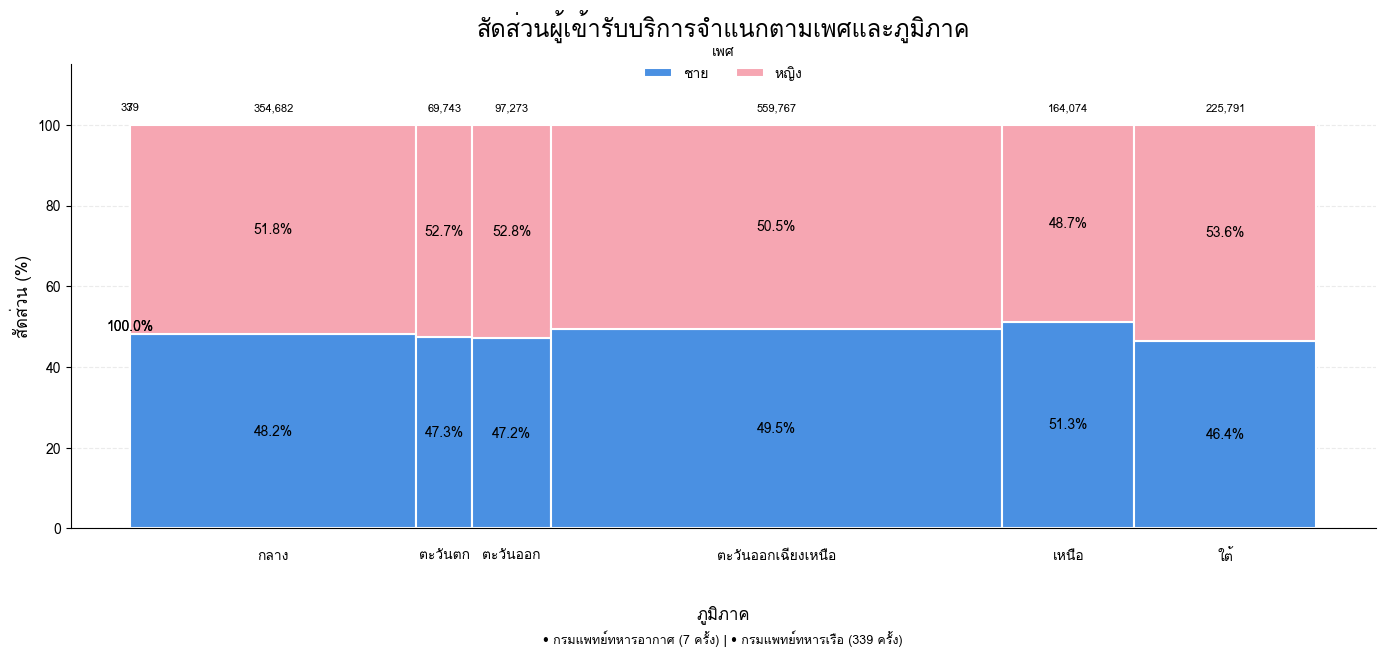

In [98]:
# ==========================================
# สัดส่วนผู้เข้ารับบริการจำแนกตามเพศและภูมิภาค
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# 1. แปลงรหัสเพศ
# -------------------------
data["gender_label"] = data["gender"].map({
    1: "ชาย",
    2: "หญิง"
}).fillna("ไม่ระบุ")


# -------------------------
# 2. รวมจำนวนบริการตามภาคและเพศ
# -------------------------
region_gender = (
    data.groupby(["ภาค", "gender_label"])["n_service"]
    .sum()
    .unstack(fill_value=0)
)

# เอาเฉพาะชายและหญิง
region_gender = region_gender.reindex(
    columns=["ชาย", "หญิง"],
    fill_value=0
)


# -------------------------
# 3. จำนวนบริการรวมแต่ละภาค
# -------------------------
total_region = region_gender.sum(axis=1)

# ความกว้างของแต่ละภาค
widths = total_region / total_region.sum()


# -------------------------
# 4. กำหนดสี
# -------------------------
male_color = "#4A90E2"      # ฟ้า
female_color = "#F6A6B2"    # ชมพูอ่อน


# -------------------------
# 5. สร้างกราฟ
# -------------------------
fig, ax = plt.subplots(figsize=(15, 8))

left = 0

for region in region_gender.index:

    width = widths[region]

    male = region_gender.loc[region, "ชาย"]
    female = region_gender.loc[region, "หญิง"]

    total = male + female

    # คำนวณเปอร์เซ็นต์
    male_pct = (male / total) * 100
    female_pct = (female / total) * 100

    # -------------------------
    # แท่งชาย
    # -------------------------
    ax.bar(
        left + width / 2,
        male_pct,
        width=width,
        color=male_color,
        edgecolor="white",
        linewidth=1.5
    )

    # -------------------------
    # แท่งหญิง
    # -------------------------
    ax.bar(
        left + width / 2,
        female_pct,
        bottom=male_pct,
        width=width,
        color=female_color,
        edgecolor="white",
        linewidth=1.5
    )

    # -------------------------
    # เปอร์เซ็นต์ชาย
    # -------------------------
    if male_pct >= 8:
        ax.text(
            left + width / 2,
            male_pct / 2,
            f"{male_pct:.1f}%",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

    # -------------------------
    # เปอร์เซ็นต์หญิง
    # -------------------------
    if female_pct >= 8:
        ax.text(
            left + width / 2,
            male_pct + (female_pct / 2),
            f"{female_pct:.1f}%",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

    # -------------------------
    # จำนวนบริการรวมด้านบน
    # -------------------------
    ax.text(
        left + width / 2,
        103,
        f"{total:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

    left += width


# -------------------------
# 6. ตั้งค่ากราฟ
# -------------------------

ax.set_ylim(0, 115)

ax.set_ylabel(
    "สัดส่วน (%)",
    fontsize=12
)

ax.set_xlabel(
    "ภูมิภาค",
    fontsize=12,
    labelpad=55
)

ax.set_title(
    "สัดส่วนผู้เข้ารับบริการจำแนกตามเพศและภูมิภาค",
    fontsize=17,
    fontweight="bold",
    pad=20
)


# -------------------------
# 7. ไม่แสดง Tick แกน X
# -------------------------

ax.set_xticks([])


# -------------------------
# 8. Grid
# -------------------------

ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)


# -------------------------
# 9. ลบกรอบที่ไม่จำเป็น
# -------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# -------------------------
# 10. แสดงชื่อภาค
# -------------------------

left = 0

for region in region_gender.index:

    width = widths[region]

    # ไม่ใส่ชื่อกรมแพทย์ตรงใต้แท่ง
    if "กรมแพทย์" not in region:

        ax.text(
            left + width / 2,
            -5,
            region,
            ha="center",
            va="top",
            fontsize=10,
            fontweight="bold"
        )

    left += width


# -------------------------
# 11. แสดงชื่อกรมแพทย์แยกด้านล่าง
# -------------------------

special_regions = [
    region for region in region_gender.index
    if "กรมแพทย์" in region
]

special_text = []

for region in special_regions:

    total = total_region[region]

    special_text.append(
        f"• {region} ({total:,.0f} ครั้ง)"
    )

if special_text:

    ax.text(
        0.5,
        -0.22,
        " | ".join(special_text),
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9
    )


# -------------------------
# 12. Legend
# -------------------------

ax.legend(
    ["ชาย", "หญิง"],
    title="เพศ",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),
    ncol=2,
    frameon=False
)


# -------------------------
# 13. จัด Layout
# -------------------------

plt.subplots_adjust(
    bottom=0.30,
    top=0.88,
    left=0.08,
    right=0.95
)

plt.show()

##**จำนวนครั้งเข้ารับบริการจำแนกตามเดือนและเพศ**

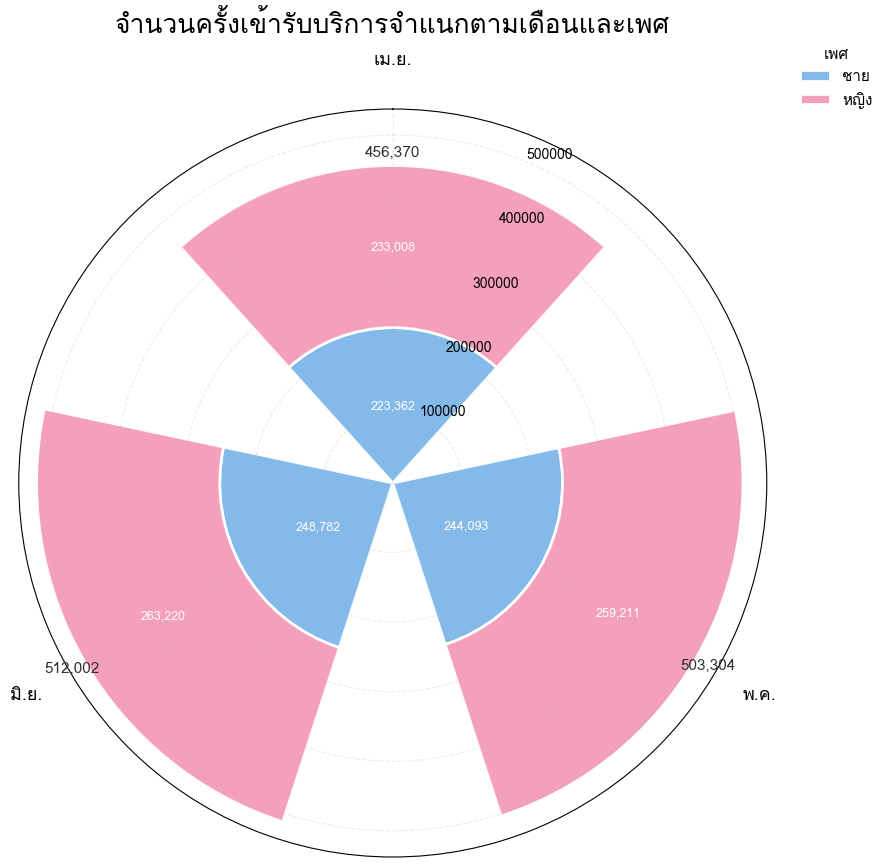

In [94]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# สัดส่วนจำนวนครั้งเข้ารับบริการตามเดือนและเพศ
# ==========================================

data["gender_label"] = data["gender"].map({
    1: "ชาย",
    2: "หญิง"
})

data["date"] = pd.to_datetime(
    data["month_no"].astype(str),
    format="%Y%m"
)

data["month"] = data["date"].dt.month

monthly_gender = (
    data.groupby(["month", "gender_label"])["n_service"]
    .sum()
    .unstack(fill_value=0)
)

monthly_gender = monthly_gender.reindex([4, 5, 6])

month_names = {
    4: "เม.ย.",
    5: "พ.ค.",
    6: "มิ.ย."
}

labels = [
    month_names[m]
    for m in monthly_gender.index
]


# ==========================================
# ตำแหน่งรอบวง
# ==========================================

theta = np.linspace(
    0,
    2 * np.pi,
    len(monthly_gender),
    endpoint=False
)

width = 2 * np.pi / len(monthly_gender) * 0.70

male = monthly_gender["ชาย"].values
female = monthly_gender["หญิง"].values


# ==========================================
# สร้างกราฟ
# ==========================================

fig, ax = plt.subplots(
    figsize=(11, 11),
    subplot_kw={"projection": "polar"}
)

male_color = "#7DB7E8"
female_color = "#F49AB8"


# ==========================================
# แท่งชาย
# ==========================================

ax.bar(
    theta,
    male,
    width=width,
    color=male_color,
    edgecolor="white",
    linewidth=2,
    alpha=0.95,
    label="ชาย"
)


# ==========================================
# แท่งหญิง
# ==========================================

ax.bar(
    theta,
    female,
    width=width,
    bottom=male,
    color=female_color,
    edgecolor="white",
    linewidth=2,
    alpha=0.95,
    label="หญิง"
)


# ==========================================
# ชื่อเดือน
# ==========================================

ax.set_xticks(theta)

ax.set_xticklabels(
    labels,
    fontsize=13,
    fontweight="bold"
)

# ระยะชื่อเดือนจากกราฟ
ax.tick_params(
    axis="x",
    pad=25
)


# ==========================================
# ⭐ ชื่อกราฟ — ยกขึ้นสูง
# ==========================================

ax.set_title(
    "จำนวนครั้งเข้ารับบริการจำแนกตามเดือนและเพศ",
    fontsize=19,
    fontweight="bold",
    pad=55
)


# ==========================================
# Grid
# ==========================================

ax.grid(
    linestyle="--",
    alpha=0.25
)


# ==========================================
# Legend
# ==========================================

ax.legend(
    title="เพศ",
    loc="upper right",
    bbox_to_anchor=(1.16, 1.10),
    frameon=False,
    fontsize=11,
    title_fontsize=11
)


# ==========================================
# จำนวนรวมแต่ละเดือน
# ==========================================

for i, month in enumerate(monthly_gender.index):

    total = monthly_gender.loc[month].sum()

    ax.text(
        theta[i],
        total + total * 0.04,
        f"{total:,.0f}",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#333333"
    )


# ==========================================
# จำนวนชาย
# ==========================================

for i, value in enumerate(male):

    if value > 0:

        ax.text(
            theta[i],
            value / 2,
            f"{value:,.0f}",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="white"
        )


# ==========================================
# จำนวนหญิง
# ==========================================

for i, value in enumerate(female):

    if value > 0:

        ax.text(
            theta[i],
            male[i] + value / 2,
            f"{value:,.0f}",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="white"
        )


# ==========================================
# ปรับทิศทาง
# ==========================================

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)


# ==========================================
# ⭐ เพิ่มพื้นที่ด้านบน
# ==========================================

plt.subplots_adjust(
    top=0.78,
    bottom=0.10,
    left=0.08,
    right=0.88
)

plt.show()

##**สัดส่วนผู้เข้ารับบริการจำแนกตามภูมิภาคและเพศ**

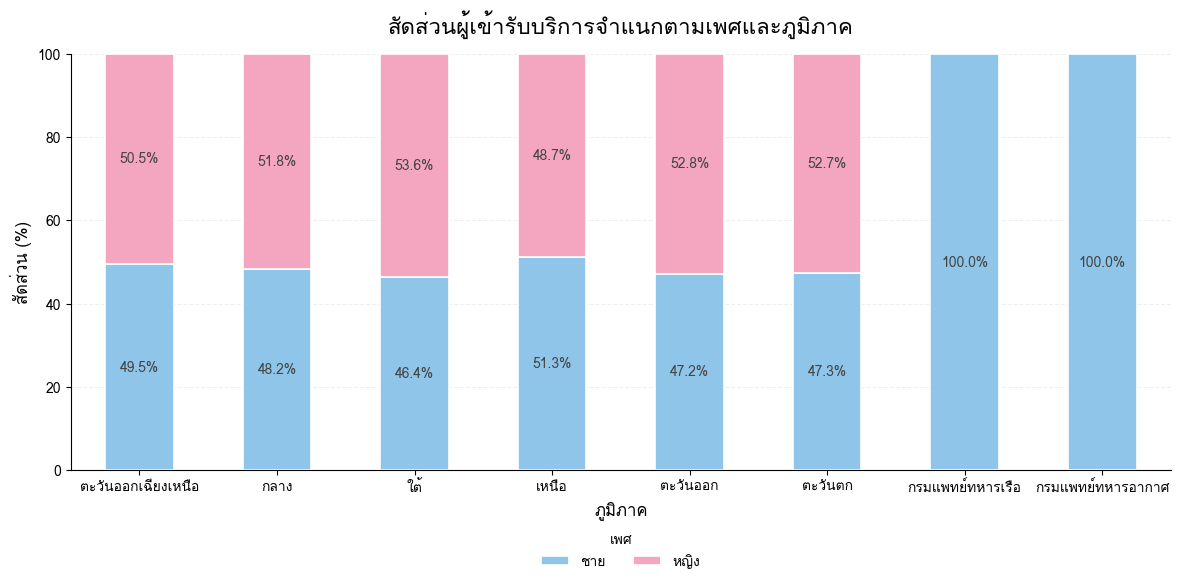

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# แปลงรหัสเพศ
data["gender_label"] = data["gender"].map({
    1: "ชาย",
    2: "หญิง"
}).fillna("ไม่ระบุ")

# รวมจำนวนครั้งเข้ารับบริการตามภูมิภาคและเพศ
region_gender = (
    data.groupby(["ภาค", "gender_label"])["n_service"]
    .sum()
    .unstack(fill_value=0)
)

# เรียงภูมิภาคตามจำนวนบริการรวมจากมากไปน้อย
region_gender = region_gender.loc[
    region_gender.sum(axis=1).sort_values(ascending=False).index
]

# แปลงเป็นเปอร์เซ็นต์
region_gender_pct = (
    region_gender.div(region_gender.sum(axis=1), axis=0) * 100
)

# ==========================================
# สีพาสเทลน่ารัก
# ==========================================
colors = {
    "ชาย": "#8EC5E8",       # ฟ้าพาสเทล
    "หญิง": "#F4A6C1",      # ชมพูพาสเทล
    "ไม่ระบุ": "#C9B8E8"    # ม่วงพาสเทล
}

# เรียงสีตามคอลัมน์ที่มีจริง
plot_colors = [
    colors[col] for col in region_gender_pct.columns
]

# ==========================================
# วาดกราฟ
# ==========================================
fig, ax = plt.subplots(figsize=(12, 6))

region_gender_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=plot_colors,
    edgecolor="white",
    linewidth=1.2,
    ax=ax
)

# ชื่อกราฟ
ax.set_title(
    "สัดส่วนผู้เข้ารับบริการจำแนกตามเพศและภูมิภาค",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("ภูมิภาค", fontsize=12)
ax.set_ylabel("สัดส่วน (%)", fontsize=12)

ax.set_ylim(0, 100)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)

# ==========================================
# ใส่เปอร์เซ็นต์บนแท่ง
# ==========================================
for container in ax.containers:

    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() >= 5
        else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=10,
        fontweight="bold",
        color="#444444"
    )

# ==========================================
# Grid
# ==========================================
ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.2
)

ax.set_axisbelow(True)

# ลบเส้นกรอบด้านบนและขวา
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ==========================================
# Legend
# ==========================================
ax.legend(
    title="เพศ",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.show()

##**TOP 10 กลุ่มโรคที่มีจำนวนครั้งเข้ารับบริการสูงสุด**

Top 10 กลุ่มโรคที่มีจำนวนครั้งเข้ารับบริการสูงสุด


,อันดับ,กลุ่มโรค,จำนวนครั้งเข้ารับบริการ
0,1,Diarrhoea and gastroenteritis of presumed infe...,"73,410"
1,2,Pneumonia organism unspecified,"44,476"
2,3,Senile cataract,"44,020"
3,4,Chronic renal failure,"30,919"
4,5,Thalassaemia,"30,446"
5,6,Non-insulin-dependent diabetes mellitus,"30,199"
6,7,Cerebral infarction,"29,448"
7,8,Other disorders of urinary system,"29,062"
8,9,Other chronic obstructive pulmonary disease,"28,492"
9,10,Heart failure,"25,183"


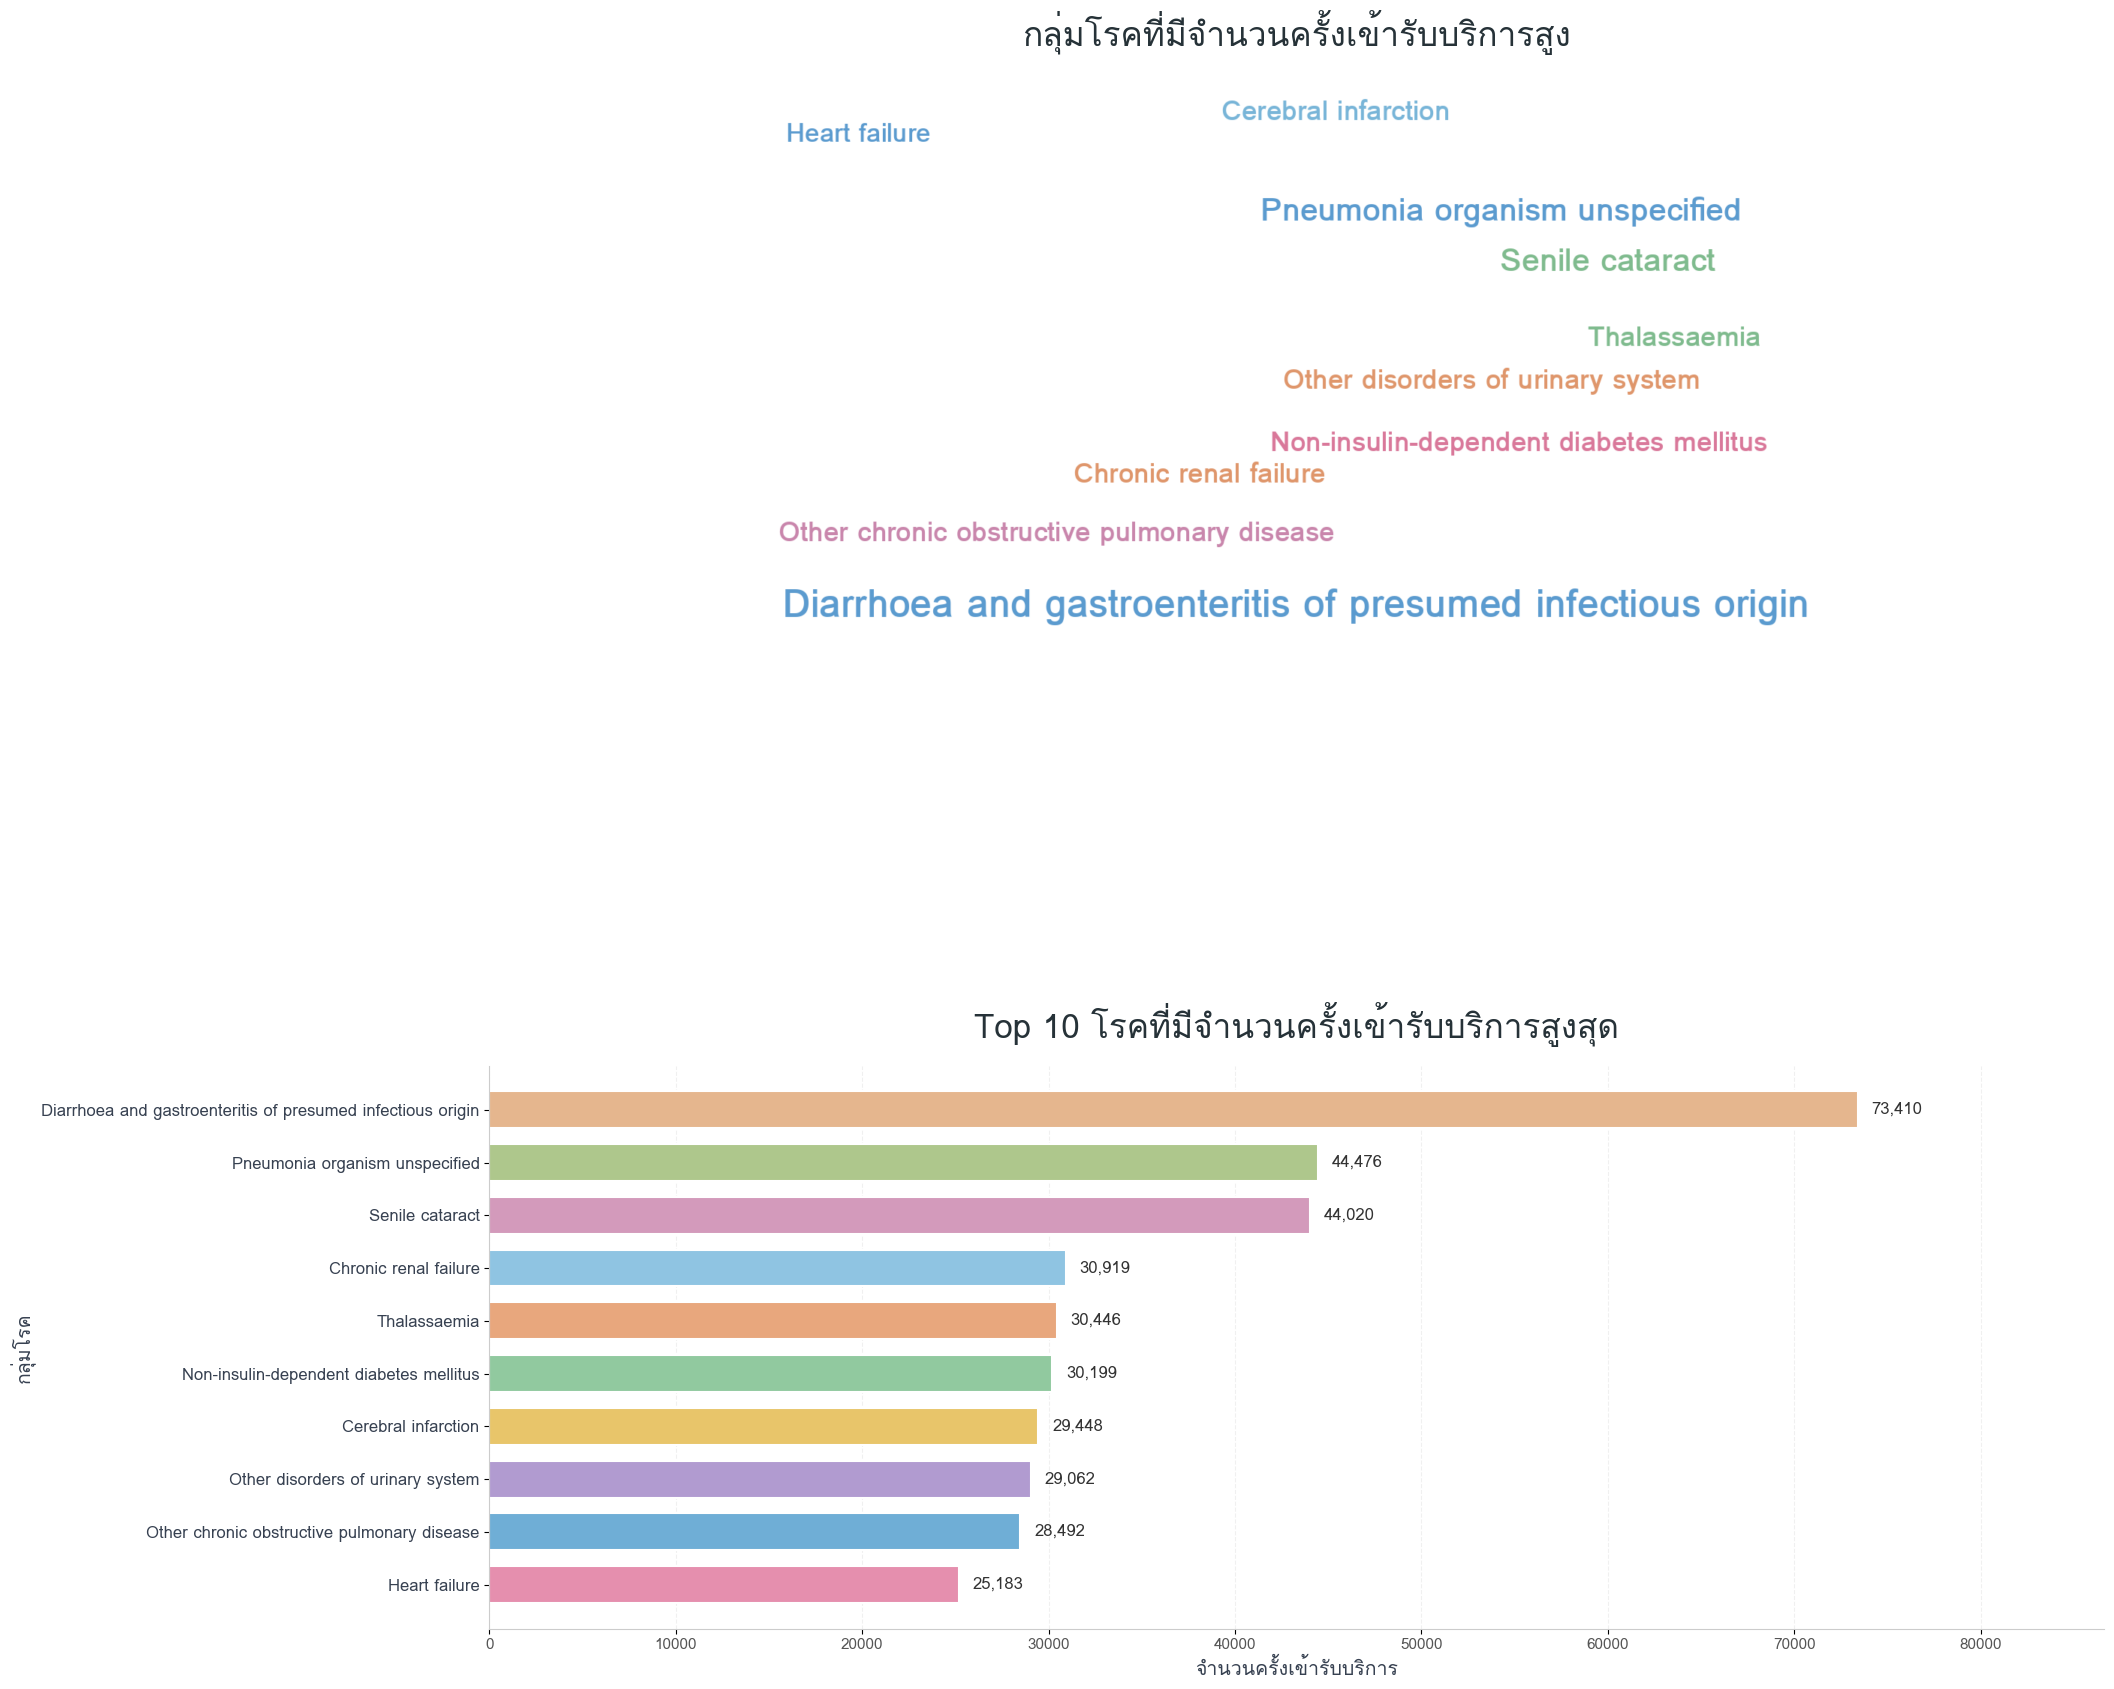

In [90]:
# ============================================================
# TOP 10 กลุ่มโรคที่มีจำนวนครั้งเข้ารับบริการสูงสุด
# Table + Word Cloud + Bar Chart
# ============================================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import random
import os

# ------------------------------------------------------------
# 1) หา Top 10 โรค
# ------------------------------------------------------------

disease_counts = (
    data.groupby("pdx_name")["n_service"]
    .sum()
    .sort_values(ascending=False)
)

top10 = disease_counts.head(10)


# ------------------------------------------------------------
# 2) แสดงตาราง Top 10
# ------------------------------------------------------------

top10_table = top10.reset_index()

top10_table.columns = [
    "กลุ่มโรค",
    "จำนวนครั้งเข้ารับบริการ"
]

top10_table["อันดับ"] = range(1, len(top10_table) + 1)

top10_table = top10_table[
    ["อันดับ", "กลุ่มโรค", "จำนวนครั้งเข้ารับบริการ"]
]

top10_table["จำนวนครั้งเข้ารับบริการ"] = (
    top10_table["จำนวนครั้งเข้ารับบริการ"]
    .map("{:,.0f}".format)
)

print("Top 10 กลุ่มโรคที่มีจำนวนครั้งเข้ารับบริการสูงสุด")
display(top10_table)


# ============================================================
# 3) Word Cloud
# ============================================================

# ฟอนต์ตัวหนา
font_path = "/usr/share/fonts/truetype/tlwg/Loma-Bold.ttf"

# ถ้าไม่มี Loma-Bold ให้ใช้ Loma ปกติ
if not os.path.exists(font_path):
    font_path = "/usr/share/fonts/truetype/tlwg/Loma.ttf"


# ------------------------------------------------------------
# สี Word Cloud
# ------------------------------------------------------------

wordcloud_colors = [
    "#D9789A",  # ชมพู
    "#5B9BCF",  # ฟ้า
    "#9B83C1",  # ม่วง
    "#DDBB5A",  # เหลือง
    "#7FBB8E",  # เขียว
    "#DF966B",  # ส้ม
    "#78B5D8",  # ฟ้าอ่อน
    "#C986AC",  # ชมพูม่วง
    "#9FB878",  # เขียวอ่อน
    "#DDA77D"   # พีช
]


def dark_color_func(
    word,
    font_size,
    position,
    orientation,
    random_state=None,
    **kwargs
):
    return random.choice(wordcloud_colors)


# ------------------------------------------------------------
# ใช้ Top 10 โดยตรง
# ------------------------------------------------------------

top10_wordcloud = {
    str(disease): int(value)
    for disease, value in top10.items()
}


# ------------------------------------------------------------
# สร้าง Word Cloud
# ------------------------------------------------------------

wordcloud = WordCloud(
    width=1400,
    height=750,
    background_color="white",
    font_path=font_path,

    # ⭐ แสดงสูงสุด 10 กลุ่มโรค
    max_words=10,

    # ลดขนาดเพื่อให้มีพื้นที่สำหรับครบ 10
    min_font_size=20,
    max_font_size=100,

    # ลดความแตกต่างของขนาด
    relative_scaling=0.45,

    # แนวนอนเป็นหลัก
    prefer_horizontal=0.95,

    # ไม่สร้างคำผสม
    collocations=False,

    # เพิ่มพื้นที่ระหว่างคำ
    margin=12,

    # สี
    color_func=dark_color_func,

    # ไม่ให้คำซ้ำ
    repeat=False

).generate_from_frequencies(top10_wordcloud)


# ============================================================
# 4) สีสำหรับ Bar Chart
# ============================================================

pastel_colors = [
    "#E58FAE",  # ชมพู
    "#6FAED6",  # ฟ้า
    "#B19BD0",  # ม่วง
    "#E8C56A",  # เหลือง
    "#91C99F",  # เขียว
    "#E8A77D",  # ส้ม
    "#8FC4E2",  # ฟ้าอ่อน
    "#D39ABB",  # ชมพูม่วง
    "#AEC78C",  # เขียวอ่อน
    "#E5B68E"   # พีช
]


# ============================================================
# 5) สร้าง Figure
#    แถวบน = Word Cloud
#    แถวล่าง = Bar Chart
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(19, 18),
    gridspec_kw={"height_ratios": [1, 1]}
)


# ------------------------------------------------------------
# Word Cloud
# ------------------------------------------------------------

axes[0].imshow(
    wordcloud,
    interpolation="bilinear"
)

axes[0].axis("off")

# ⭐ ชื่อหัวข้อเดิม — ไม่เปลี่ยน
axes[0].set_title(
    "กลุ่มโรคที่มีจำนวนครั้งเข้ารับบริการสูง",
    fontsize=24,
    fontweight="bold",
    color="#263238",
    pad=25
)


# ------------------------------------------------------------
# Bar Chart
# ------------------------------------------------------------

bars = axes[1].barh(
    top10.index[::-1],
    top10.values[::-1],
    color=pastel_colors,
    edgecolor="white",
    linewidth=1.5,
    height=0.7
)


axes[1].set_title(
    "Top 10 โรคที่มีจำนวนครั้งเข้ารับบริการสูงสุด",
    fontsize=24,
    fontweight="bold",
    color="#263238",
    pad=20
)


axes[1].set_xlabel(
    "จำนวนครั้งเข้ารับบริการ",
    fontsize=14,
    fontweight="bold",
    color="#374151"
)


axes[1].set_ylabel(
    "กลุ่มโรค",
    fontsize=14,
    fontweight="bold",
    color="#374151"
)


# ------------------------------------------------------------
# ปรับตัวอักษรแกน
# ------------------------------------------------------------

for label in axes[1].get_yticklabels():
    label.set_fontsize(12)
    label.set_fontweight("bold")
    label.set_color("#374151")


for label in axes[1].get_xticklabels():
    label.set_fontsize(11)
    label.set_fontweight("bold")
    label.set_color("#555555")


# ------------------------------------------------------------
# ใส่ตัวเลขบนแท่งกราฟ
# ------------------------------------------------------------

for bar, value in zip(
    bars,
    top10.values[::-1]
):
    axes[1].text(
        value + top10.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="#333333"
    )


# ------------------------------------------------------------
# Grid และเส้นกรอบ
# ------------------------------------------------------------

axes[1].xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.8,
    alpha=0.18
)

axes[1].set_axisbelow(True)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

axes[1].spines["left"].set_color("#CCCCCC")
axes[1].spines["bottom"].set_color("#CCCCCC")


# ------------------------------------------------------------
# เพิ่มพื้นที่ด้านขวาให้ตัวเลข
# ------------------------------------------------------------

axes[1].set_xlim(
    0,
    top10.max() * 1.18
)


# ============================================================
# 6) ปรับระยะห่าง
# ============================================================

plt.subplots_adjust(
    hspace=0.75,
    top=0.93,
    bottom=0.07,
    left=0.12,
    right=0.97
)

plt.show()

##**แนวโน้มจำนวนครั้งเข้ารับบริการรายเดือน**

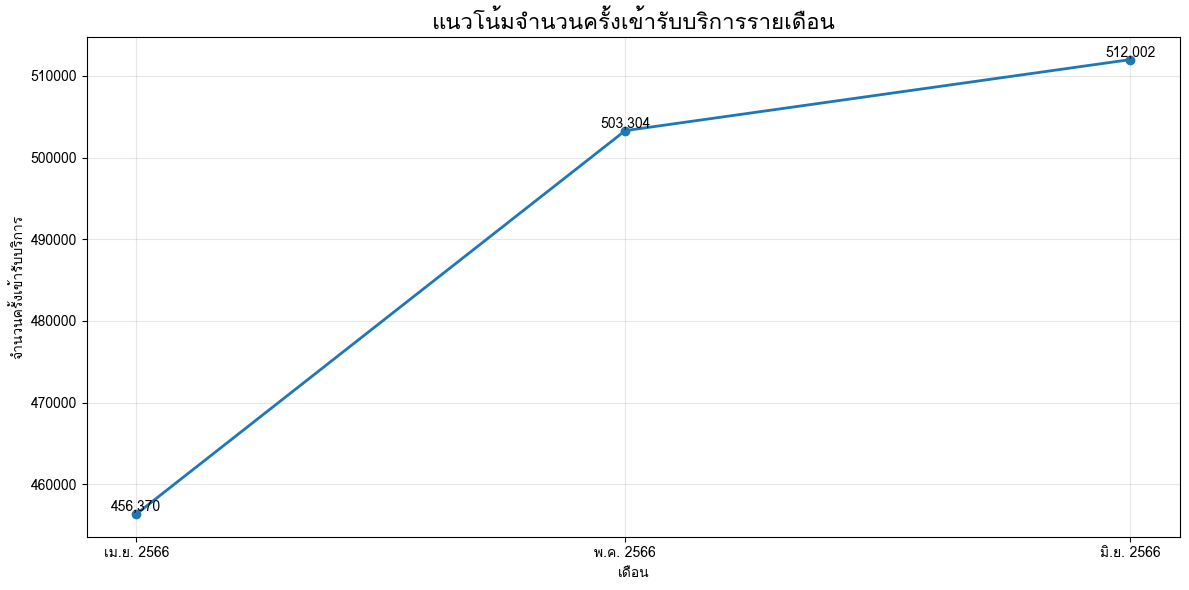

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# แปลง month_no เป็นวันที่
data["date"] = pd.to_datetime(
    data["month_no"].astype(str),
    format="%Y%m",
    errors="coerce"
)

# รวมจำนวนครั้งเข้ารับบริการในแต่ละเดือน
monthly_service = (
    data.groupby("date")["n_service"]
    .sum()
    .sort_index()
)

# สร้างกราฟ
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_service.index,
    monthly_service.values,
    marker="o",
    linewidth=2
)

# ใส่จำนวนบนจุด
for x, y in zip(monthly_service.index, monthly_service.values):
    plt.text(
        x,
        y,
        f"{y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(
    "แนวโน้มจำนวนครั้งเข้ารับบริการรายเดือน",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("เดือน")
plt.ylabel("จำนวนครั้งเข้ารับบริการ")

plt.xticks(
    monthly_service.index,
    ["เม.ย. 2566", "พ.ค. 2566", "มิ.ย. 2566"]
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##**Top 5 จังหวัดที่มีจำนวนครั้งเข้ารับบริการสูงสุด**

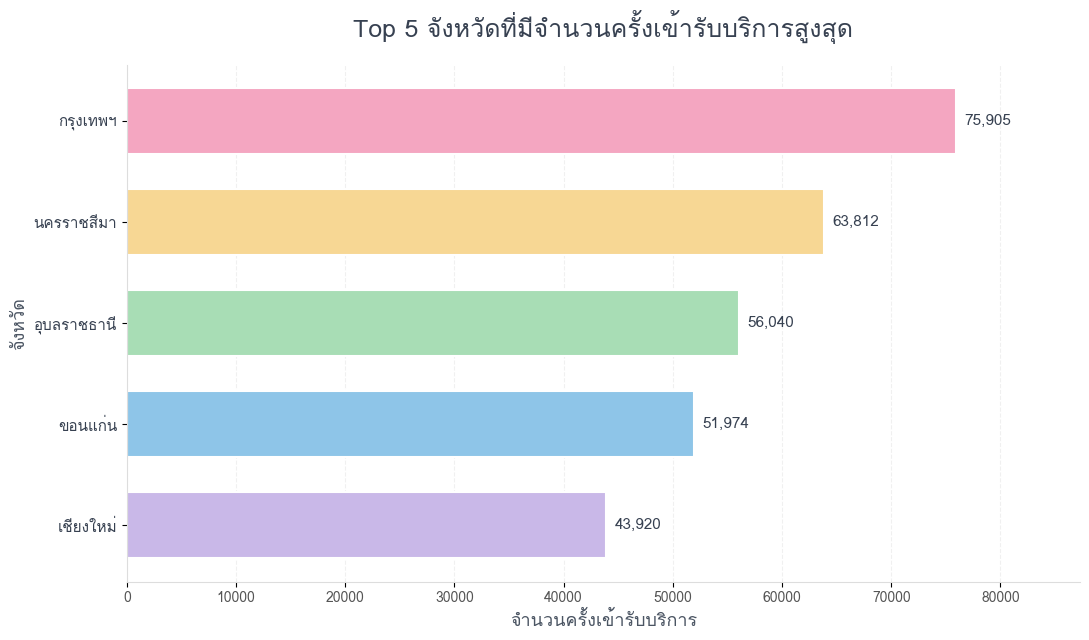

In [86]:
import matplotlib.pyplot as plt

# ============================================================
# รวมจำนวนครั้งเข้ารับบริการตามจังหวัด
# ============================================================

province_service = (
    data.groupby("prov")["n_service"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

# เรียงจากน้อย → มาก
province_service = province_service.sort_values()


# ============================================================
# สี Pastel น่ารัก ๆ
# ============================================================

cute_colors = [
    "#C9B8E8",  # ม่วงพาสเทล
    "#8EC5E8",  # ฟ้าพาสเทล
    "#A8DDB5",  # เขียวพาสเทล
    "#F7D794",  # เหลืองพาสเทล
    "#F4A6C1"   # ชมพูพาสเทล
]


# ============================================================
# สร้างกราฟ
# ============================================================

plt.figure(figsize=(11, 6.5))

bars = plt.barh(
    province_service.index,
    province_service.values,
    color=cute_colors,
    edgecolor="white",
    linewidth=1.5,
    height=0.65
)


# ============================================================
# ชื่อกราฟ
# ============================================================

plt.title(
    "Top 5 จังหวัดที่มีจำนวนครั้งเข้ารับบริการสูงสุด",
    fontsize=18,
    fontweight="bold",
    color="#374151",
    pad=20
)

plt.xlabel(
    "จำนวนครั้งเข้ารับบริการ",
    fontsize=13,
    fontweight="bold",
    color="#4B5563"
)

plt.ylabel(
    "จังหวัด",
    fontsize=13,
    fontweight="bold",
    color="#4B5563"
)


# ============================================================
# ใส่ตัวเลขปลายแท่ง
# ============================================================

max_value = province_service.max()

for bar, value in zip(
    bars,
    province_service.values
):
    plt.text(
        value + max_value * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#374151"
    )


# ============================================================
# ตกแต่งแกน
# ============================================================

plt.xticks(
    fontsize=10,
    color="#555555"
)

plt.yticks(
    fontsize=11,
    fontweight="bold",
    color="#374151"
)


# ============================================================
# Grid
# ============================================================

plt.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.18
)

plt.gca().set_axisbelow(True)


# ============================================================
# เอาเส้นกรอบบางส่วนออก
# ============================================================

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.gca().spines["left"].set_color("#DDDDDD")
plt.gca().spines["bottom"].set_color("#DDDDDD")


# เพิ่มพื้นที่ด้านขวาให้ตัวเลข
plt.xlim(
    0,
    max_value * 1.15
)

plt.tight_layout()
plt.show()

##**รวมจำนวนครั้งเข้ารับบริการตามภาคและเขตสุขภาพ**


🌸 เขตสุขภาพที่มีจำนวนครั้งเข้ารับบริการสูงสุดในแต่ละภูมิภาค


อันดับ,ภูมิภาค,เขตสุขภาพที่มีจำนวนบริการสูงสุด,จำนวนครั้งเข้ารับบริการ
1,ตะวันออกเฉียงเหนือ,เขต 9 นครราชสีมา,"162,269"
2,เหนือ,เขต 1 เชียงใหม่,"151,918"
3,ใต้,เขต 12 สงขลา,"117,600"
4,ตะวันออก,เขต 6 ระยอง,"97,273"
5,กลาง,เขต 4 สระบุรี,"89,565"
6,ตะวันตก,เขต 5 ราชบุรี,"56,966"
7,กรมแพทย์ทหารเรือ,กรมแพทย์ทหาร,339
8,กรมแพทย์ทหารอากาศ,กรมแพทย์ทหาร,7


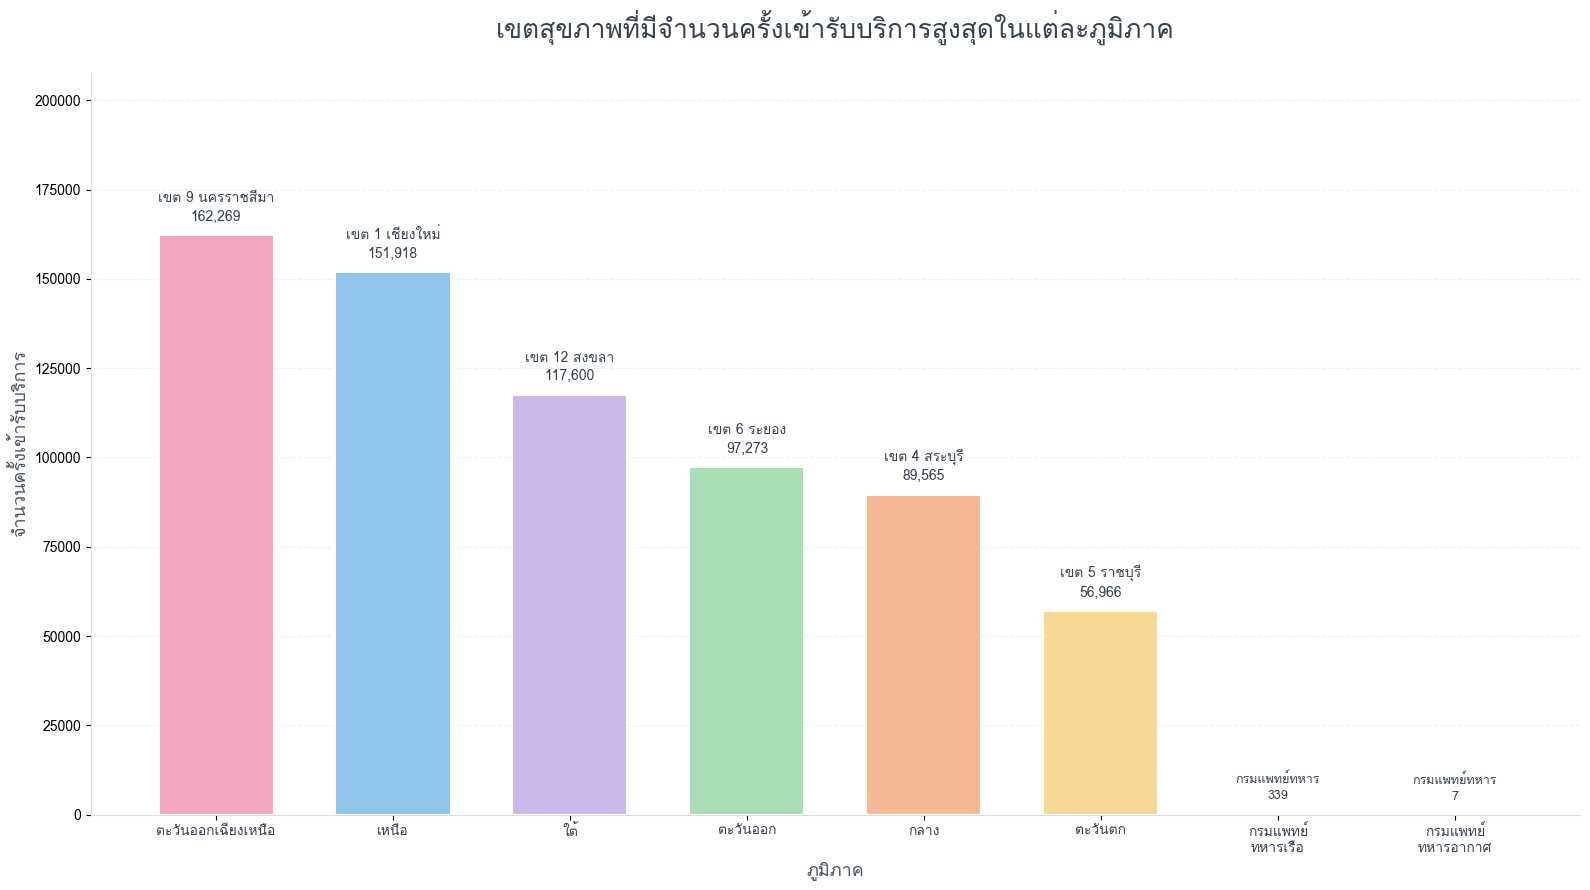

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) รวมจำนวนครั้งเข้ารับบริการตามภาคและเขตสุขภาพ
# ============================================================

region_zone = (
    data.groupby(["ภาค", "nhso_zonename"])["n_service"]
    .sum()
    .reset_index()
)


# ============================================================
# 2) หาเขตสุขภาพที่มีจำนวนบริการสูงสุดของแต่ละภาค
# ============================================================

top_zone_region = (
    region_zone
    .sort_values("n_service", ascending=False)
    .groupby("ภาค")
    .head(1)
    .reset_index(drop=True)
)


# ============================================================
# 3) สร้างตารางสวย ๆ
# ============================================================

table_data = top_zone_region.copy()

table_data["อันดับ"] = range(1, len(table_data) + 1)

table_data = table_data[
    ["อันดับ", "ภาค", "nhso_zonename", "n_service"]
]

table_data.columns = [
    "อันดับ",
    "ภูมิภาค",
    "เขตสุขภาพที่มีจำนวนบริการสูงสุด",
    "จำนวนครั้งเข้ารับบริการ"
]

table_data["จำนวนครั้งเข้ารับบริการ"] = (
    table_data["จำนวนครั้งเข้ารับบริการ"]
    .map("{:,.0f}".format)
)

print("🌸 เขตสุขภาพที่มีจำนวนครั้งเข้ารับบริการสูงสุดในแต่ละภูมิภาค")

display(
    table_data.style
    .hide(axis="index")
    .set_caption(
        "เขตสุขภาพที่มีจำนวนครั้งเข้ารับบริการสูงสุดในแต่ละภูมิภาค"
    )
    .set_properties(
        **{
            "font-size": "13px",
            "text-align": "center",
            "border": "1px solid #E5E7EB"
        }
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#374151"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#DCEAF7"),
                ("color", "#374151"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "9px"),
                ("text-align", "center")
            ]
        }
    ])
)


# ============================================================
# 4) สี Pastel
# ============================================================

cute_colors = [
    "#F4A6C1",  # ชมพู
    "#8EC5E8",  # ฟ้า
    "#C9B8E8",  # ม่วง
    "#A8DDB5",  # เขียว
    "#F5B895",  # พีช
    "#F7D794",  # เหลือง
    "#D9A7C7",  # ชมพูม่วง
    "#A8C8E8"   # ฟ้าอ่อน
]


# ============================================================
# 5) สร้างชื่อแกน X แบบแยกบรรทัด
# ============================================================

def format_region_name(name):

    if name == "กรมแพทย์ทหารอากาศ":
        return "กรมแพทย์\nทหารอากาศ"

    elif name == "กรมแพทย์ทหารเรือ":
        return "กรมแพทย์\nทหารเรือ"

    elif len(str(name)) > 12:
        return str(name).replace(" ", "\n")

    return str(name)


x_labels = [
    format_region_name(x)
    for x in top_zone_region["ภาค"]
]


# ============================================================
# 6) สร้างกราฟ
# ============================================================

plt.figure(figsize=(16, 9))

bars = plt.bar(
    range(len(top_zone_region)),
    top_zone_region["n_service"],
    color=cute_colors[:len(top_zone_region)],
    edgecolor="white",
    linewidth=1.5,
    width=0.65
)


# ============================================================
# 7) ชื่อกราฟ
# ============================================================

plt.title(
    "เขตสุขภาพที่มีจำนวนครั้งเข้ารับบริการสูงสุดในแต่ละภูมิภาค",
    fontsize=19,
    fontweight="bold",
    color="#374151",
    pad=25
)

plt.xlabel(
    "ภูมิภาค",
    fontsize=13,
    fontweight="bold",
    color="#4B5563"
)

plt.ylabel(
    "จำนวนครั้งเข้ารับบริการ",
    fontsize=13,
    fontweight="bold",
    color="#4B5563"
)


# ============================================================
# 8) แกน X
# ============================================================

plt.xticks(
    range(len(top_zone_region)),
    x_labels,
    fontsize=10,
    fontweight="bold",
    color="#374151"
)


# ============================================================
# 9) ใส่ชื่อเขตสุขภาพ + จำนวนบริการ
# ============================================================

max_value = top_zone_region["n_service"].max()

for i, (bar, zone, value) in enumerate(
    zip(
        bars,
        top_zone_region["nhso_zonename"],
        top_zone_region["n_service"]
    )
):

    # ถ้าเป็นกรมทหาร ให้แยกตำแหน่งออกจากกัน
    if zone == "กรมแพทย์ทหารอากาศ":
        y_offset = max_value * 0.04

    elif zone == "กรมแพทย์ทหารเรือ":
        y_offset = max_value * 0.12

    else:
        y_offset = max_value * 0.02

    # แบ่งชื่อกรมทหารเป็น 2 บรรทัด
    if zone == "กรมแพทย์ทหารอากาศ":
        zone_label = "กรมแพทย์\nทหารอากาศ"

    elif zone == "กรมแพทย์ทหารเรือ":
        zone_label = "กรมแพทย์\nทหารเรือ"

    else:
        zone_label = zone

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + y_offset,
        f"{zone_label}\n{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9 if "กรมแพทย์" in zone else 10,
        fontweight="bold",
        color="#374151",
        linespacing=1.4
    )


# ============================================================
# 10) Grid
# ============================================================

plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.18
)

plt.gca().set_axisbelow(True)


# ============================================================
# 11) ตกแต่งกรอบ
# ============================================================

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.gca().spines["left"].set_color("#DDDDDD")
plt.gca().spines["bottom"].set_color("#DDDDDD")


# ============================================================
# 12) เพิ่มพื้นที่ด้านบน
# ============================================================

plt.ylim(
    0,
    max_value * 1.28
)

plt.tight_layout()
plt.show()

🌸 Top 5 กลุ่มโรคที่มีจำนวนครั้งเข้ารับบริการสูงสุดในแต่ละฤดู


ฤดู,อันดับ,กลุ่มโรค,จำนวนครั้งเข้ารับบริการ
ฤดูร้อน,1,Diarrhoea and gastroenteritis of presumed infectious origin,"49,400"
ฤดูร้อน,2,Pneumonia organism unspecified,"28,706"
ฤดูร้อน,3,Senile cataract,"28,586"
ฤดูร้อน,4,Non-insulin-dependent diabetes mellitus,"20,149"
ฤดูร้อน,5,Chronic renal failure,"20,135"
ฤดูฝน,1,Diarrhoea and gastroenteritis of presumed infectious origin,"24,010"
ฤดูฝน,2,Pneumonia organism unspecified,"15,770"
ฤดูฝน,3,Senile cataract,"15,434"
ฤดูฝน,4,Chronic renal failure,"10,784"
ฤดูฝน,5,Thalassaemia,"10,545"


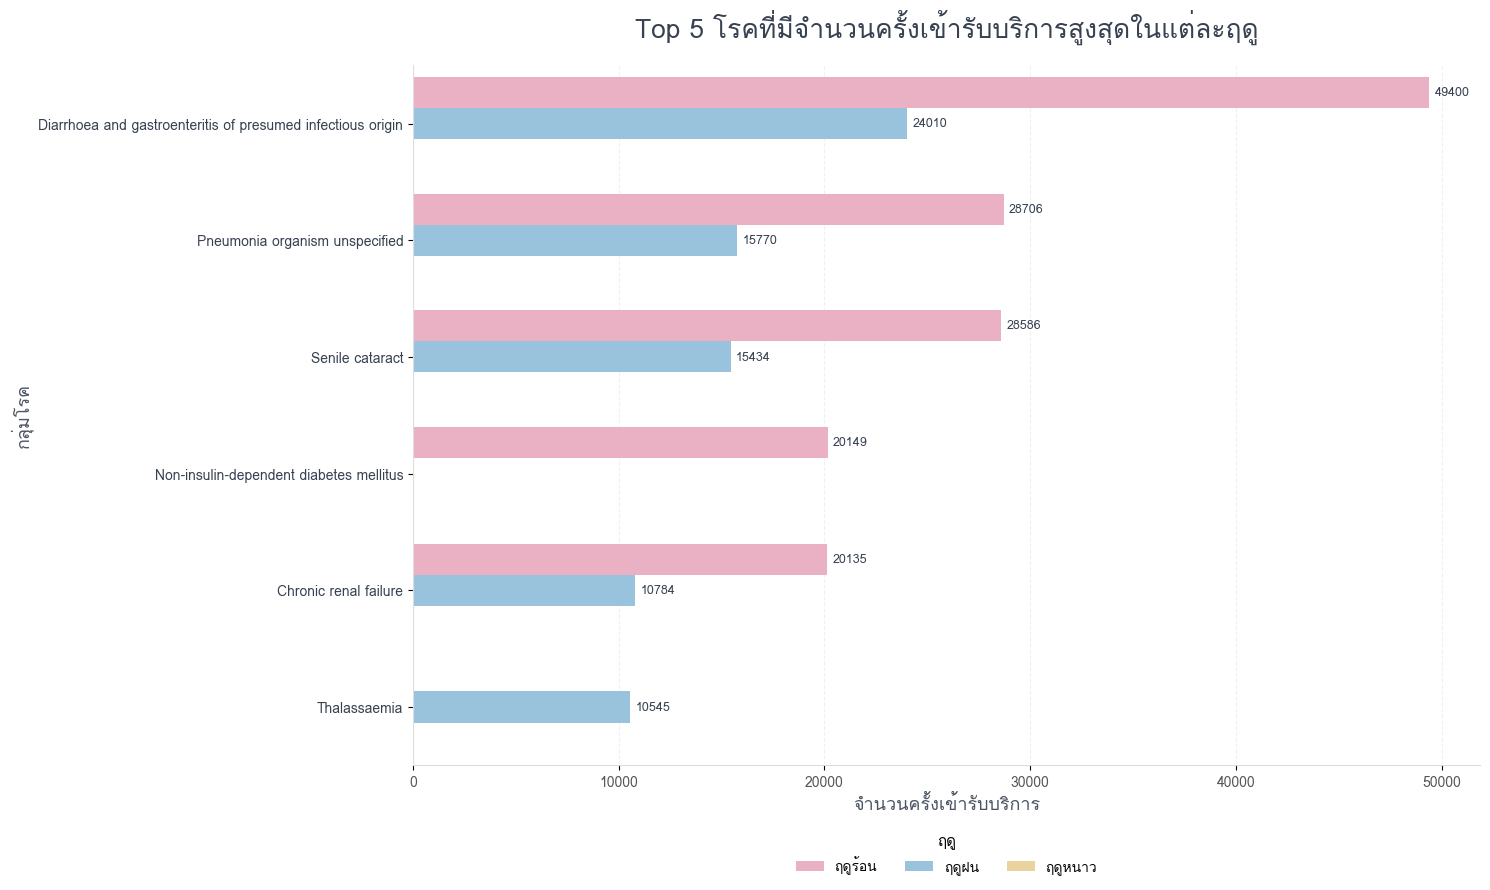

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1) สร้างเดือนจาก month_no
# ============================================================

data["date"] = pd.to_datetime(
    data["month_no"].astype(str),
    format="%Y%m",
    errors="coerce"
)

data["month"] = data["date"].dt.month


# ============================================================
# 2) แบ่งฤดูของประเทศไทย
# ============================================================

def get_season(month):
    if month in [3, 4, 5]:
        return "ฤดูร้อน"
    elif month in [6, 7, 8, 9, 10]:
        return "ฤดูฝน"
    elif month in [11, 12, 1, 2]:
        return "ฤดูหนาว"
    else:
        return None

data["season"] = data["month"].apply(get_season)


# ============================================================
# 3) รวมจำนวนบริการตามฤดูและโรค
# ============================================================

season_disease = (
    data.groupby(["season", "pdx_name"])["n_service"]
    .sum()
    .reset_index()
)


# ============================================================
# 4) เอา Top 5 โรคของแต่ละฤดู
# ============================================================

top5_season = (
    season_disease
    .sort_values(
        ["season", "n_service"],
        ascending=[True, False]
    )
    .groupby("season")
    .head(5)
)


# ============================================================
# 5) กำหนดลำดับฤดู
# ============================================================

season_order = [
    "ฤดูร้อน",
    "ฤดูฝน",
    "ฤดูหนาว"
]

top5_season["season"] = pd.Categorical(
    top5_season["season"],
    categories=season_order,
    ordered=True
)

top5_season = top5_season.sort_values(
    ["season", "n_service"],
    ascending=[True, False]
)


# ============================================================
# 6) สร้างตารางสวย ๆ
# ============================================================

table_data = top5_season.copy()

# สร้างอันดับในแต่ละฤดู
table_data["อันดับ"] = (
    table_data
    .groupby("season", observed=True)
    .cumcount() + 1
)

table_data = table_data[
    ["season", "อันดับ", "pdx_name", "n_service"]
]

table_data.columns = [
    "ฤดู",
    "อันดับ",
    "กลุ่มโรค",
    "จำนวนครั้งเข้ารับบริการ"
]

# ใส่ comma ให้ตัวเลข
table_data["จำนวนครั้งเข้ารับบริการ"] = (
    table_data["จำนวนครั้งเข้ารับบริการ"]
    .map("{:,.0f}".format)
)


# แสดงตาราง
print("Top 5 กลุ่มโรคที่มีจำนวนครั้งเข้ารับบริการสูงสุดในแต่ละฤดู")

display(
    table_data.style
    .hide(axis="index")
    .set_caption("Top 5 กลุ่มโรคจำแนกตามฤดู")
    .set_properties(
        **{
            "font-size": "13px",
            "text-align": "center",
            "border": "1px solid #E5E7EB"
        }
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#374151"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#F3DDE6"),
                ("color", "#374151"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "8px"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#FFF8FA")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "#FFFFFF")
            ]
        }
    ])
)


# ============================================================
# 7) สีของแต่ละฤดู
# ============================================================

season_colors = {
    "ฤดูร้อน": "#F4A6C1",   # ชมพูพาสเทล
    "ฤดูฝน": "#8EC5E8",     # ฟ้าพาสเทล
    "ฤดูหนาว": "#F7D794"    # เหลืองพาสเทล
}


# ============================================================
# 8) สร้างกราฟ
# ============================================================

plt.figure(figsize=(15, 9))

ax = sns.barplot(
    data=top5_season,
    x="n_service",
    y="pdx_name",
    hue="season",
    hue_order=season_order,
    palette=season_colors
)


# ============================================================
# 9) ชื่อกราฟ
# ============================================================

plt.title(
    "Top 5 โรคที่มีจำนวนครั้งเข้ารับบริการสูงสุดในแต่ละฤดู",
    fontsize=19,
    fontweight="bold",
    color="#374151",
    pad=20
)

plt.xlabel(
    "จำนวนครั้งเข้ารับบริการ",
    fontsize=13,
    fontweight="bold",
    color="#4B5563"
)

plt.ylabel(
    "กลุ่มโรค",
    fontsize=13,
    fontweight="bold",
    color="#4B5563"
)


# ============================================================
# 10) ใส่ตัวเลขปลายแท่ง
# ============================================================

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4,
        fontsize=9,
        fontweight="bold",
        color="#374151"
    )


# ============================================================
# 11) Legend
# ============================================================

plt.legend(
    title="ฤดู",
    title_fontsize=11,
    fontsize=10,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)


# ============================================================
# 12) ตกแต่งกราฟ
# ============================================================

ax.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.8,
    alpha=0.18
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#DDDDDD")
ax.spines["bottom"].set_color("#DDDDDD")

plt.xticks(
    fontsize=10,
    color="#555555"
)

plt.yticks(
    fontsize=10,
    color="#374151"
)

plt.tight_layout()
plt.show()

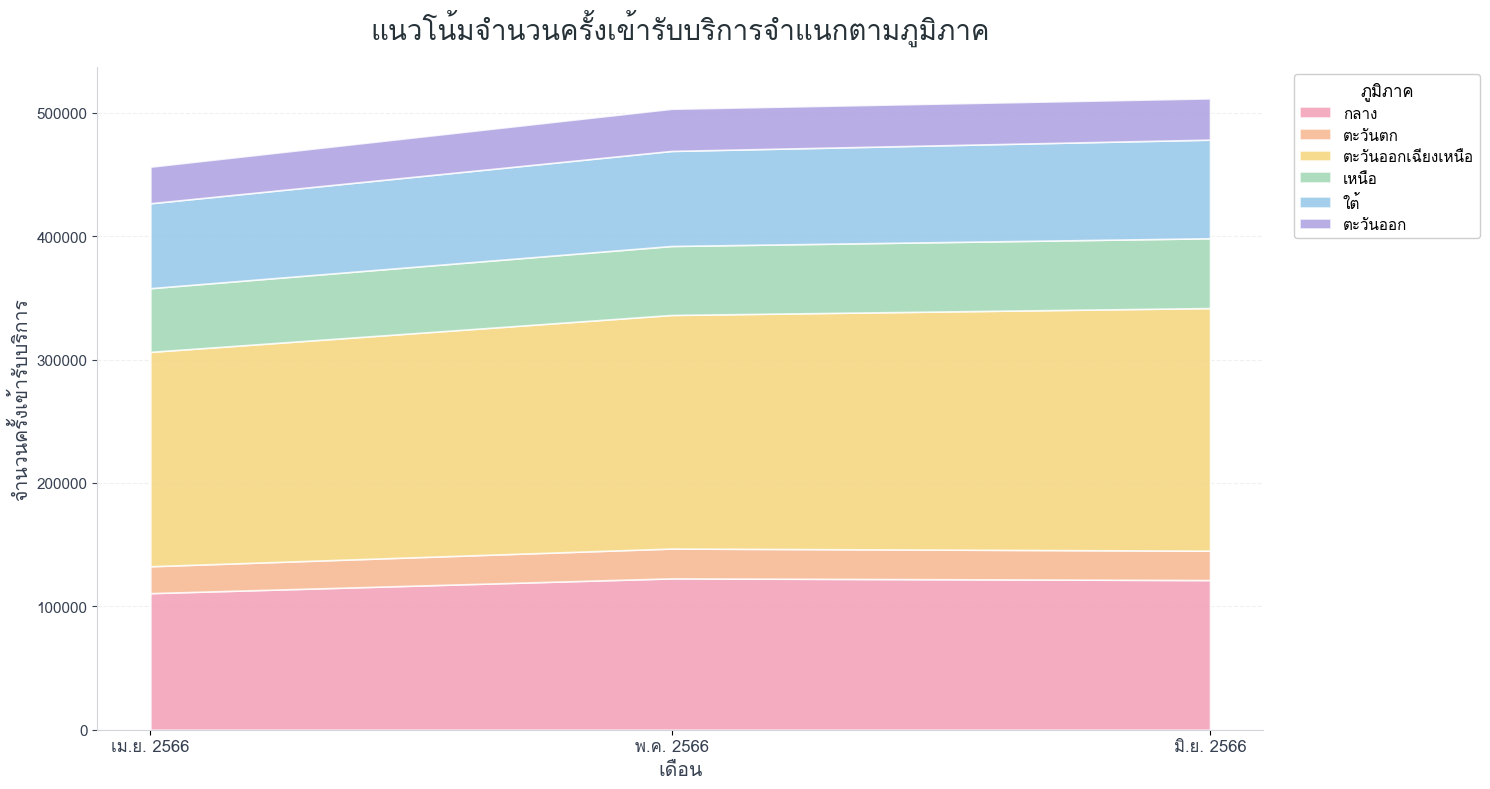

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) สร้างวันที่จาก month_no
# ============================================================

data["date"] = pd.to_datetime(
    data["month_no"].astype(str),
    format="%Y%m",
    errors="coerce"
)

# ============================================================
# 2) รวมจำนวนครั้งเข้ารับบริการตามเดือนและภูมิภาค
# ============================================================

region_month = (
    data.groupby(["date", "ภาค"])["n_service"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

# ============================================================
# 3) กำหนดชื่อเดือนภาษาไทย
# ============================================================

month_labels = {
    pd.Timestamp("2023-04-01"): "เม.ย. 2566",
    pd.Timestamp("2023-05-01"): "พ.ค. 2566",
    pd.Timestamp("2023-06-01"): "มิ.ย. 2566"
}

# ============================================================
# 4) สีแต่ละภูมิภาค
#    คนละโทน แต่ยังคงความน่ารัก / pastel
# ============================================================

region_colors = {
    "กลาง": "#F29AB2",                 # ชมพู
    "ตะวันตก": "#F6B38A",              # ส้มพีช
    "ตะวันออกเฉียงเหนือ": "#F4D477",  # เหลือง
    "เหนือ": "#9DD5B0",                # เขียวมิ้นต์
    "ใต้": "#8FC4E8",                  # ฟ้า
    "ตะวันออก": "#A99BE0",             # ม่วง
}

# ============================================================
# 5) เรียงลำดับภูมิภาค
# ============================================================

region_order = [
    "กลาง",
    "ตะวันตก",
    "ตะวันออกเฉียงเหนือ",
    "เหนือ",
    "ใต้",
    "ตะวันออก"
]

# เอาเฉพาะภูมิภาคที่มีอยู่จริงในข้อมูล
region_order = [
    region for region in region_order
    if region in region_month.columns
]

region_month = region_month[region_order]

# ============================================================
# 6) วาด Stacked Area Chart
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 8)
)

ax.stackplot(
    region_month.index,
    *[
        region_month[region]
        for region in region_order
    ],
    labels=region_order,
    colors=[
        region_colors[region]
        for region in region_order
    ],
    alpha=0.82,
    edgecolor="white",
    linewidth=1.2
)

# ============================================================
# 7) ชื่อกราฟ
# ============================================================

ax.set_title(
    "แนวโน้มจำนวนครั้งเข้ารับบริการจำแนกตามภูมิภาค",
    fontsize=20,
    fontweight="bold",
    color="#263238",
    pad=20
)

ax.set_xlabel(
    "เดือน",
    fontsize=14,
    fontweight="bold",
    color="#374151"
)

ax.set_ylabel(
    "จำนวนครั้งเข้ารับบริการ",
    fontsize=14,
    fontweight="bold",
    color="#374151"
)

# ============================================================
# 8) เปลี่ยนชื่อแกน X เป็นภาษาไทย
# ============================================================

ax.set_xticks(region_month.index)

ax.set_xticklabels(
    [
        month_labels.get(
            date,
            date.strftime("%m/%Y")
        )
        for date in region_month.index
    ],
    fontsize=12,
    fontweight="bold",
    color="#374151"
)

# ============================================================
# 9) Legend
# ============================================================

ax.legend(
    title="ภูมิภาค",
    title_fontsize=12,
    fontsize=11,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fancybox=True,
    framealpha=0.95
)

# ============================================================
# 10) Grid
# ============================================================

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.18
)

ax.set_axisbelow(True)

# ============================================================
# 11) ตกแต่งกรอบ
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D1D5DB")
ax.spines["bottom"].set_color("#D1D5DB")

ax.tick_params(
    axis="y",
    labelsize=11,
    colors="#374151"
)

# ============================================================
# 12) ปรับ Layout
# ============================================================

plt.tight_layout()

plt.show()

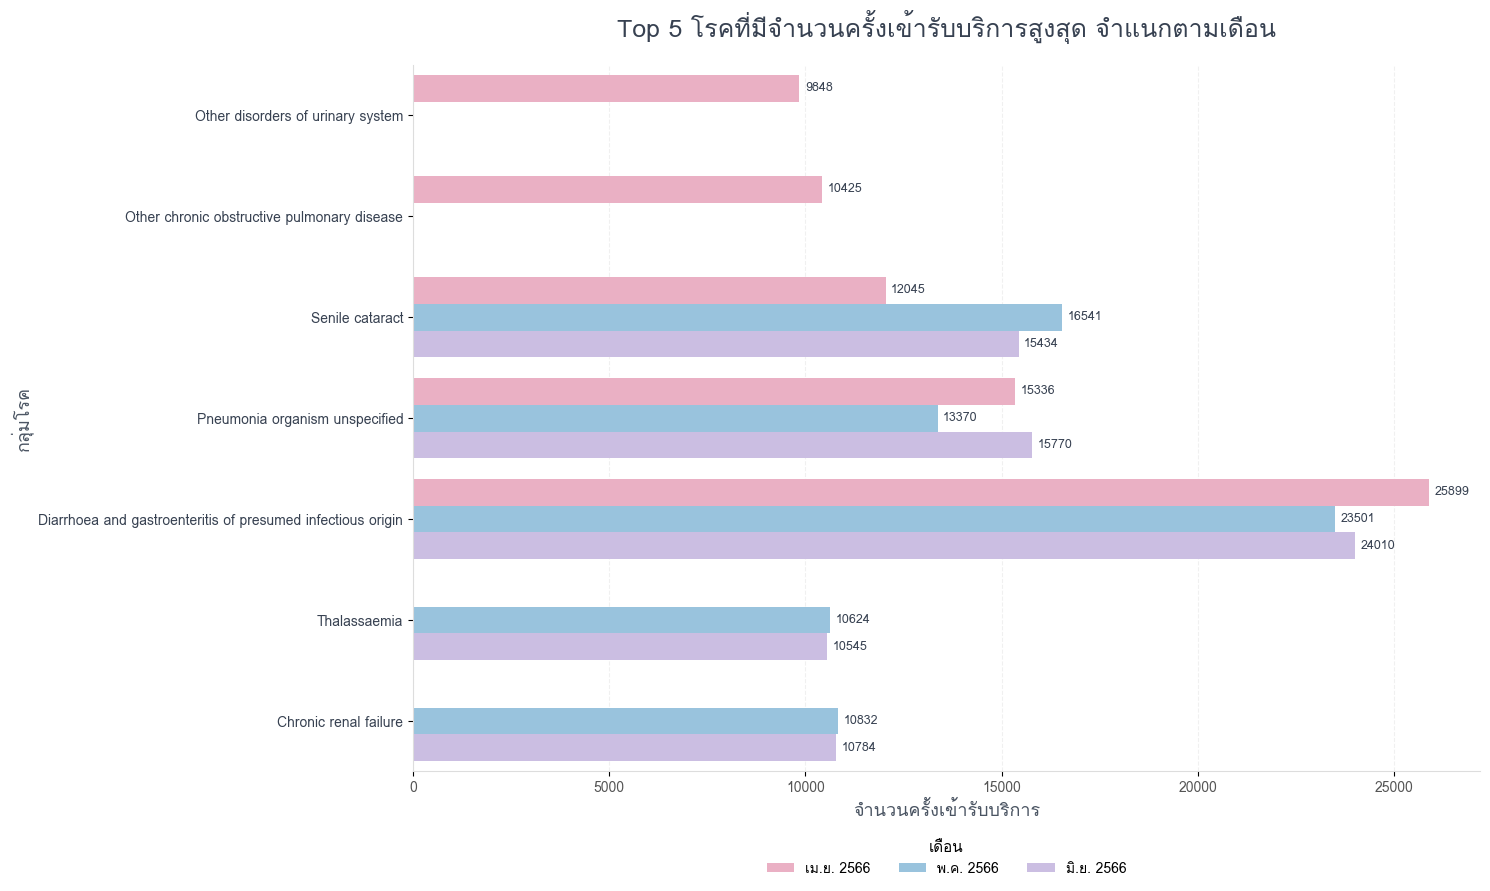

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# สร้างวันที่จาก month_no
# ============================================================

data["date"] = pd.to_datetime(
    data["month_no"].astype(str),
    format="%Y%m",
    errors="coerce"
)

# ชื่อเดือนภาษาไทย
month_names = {
    4: "เม.ย. 2566",
    5: "พ.ค. 2566",
    6: "มิ.ย. 2566"
}

data["month_name"] = data["date"].dt.month.map(month_names)


# ============================================================
# รวมจำนวนบริการตามเดือนและโรค
# ============================================================

month_disease = (
    data.groupby(["month_name", "pdx_name"])["n_service"]
    .sum()
    .reset_index()
)


# ============================================================
# เลือก Top 5 ของแต่ละเดือน
# ============================================================

top5_month = (
    month_disease
    .sort_values(
        ["month_name", "n_service"],
        ascending=[True, False]
    )
    .groupby("month_name")
    .head(5)
)


# ============================================================
# กำหนดลำดับเดือน
# ============================================================

month_order = [
    "เม.ย. 2566",
    "พ.ค. 2566",
    "มิ.ย. 2566"
]

top5_month["month_name"] = pd.Categorical(
    top5_month["month_name"],
    categories=month_order,
    ordered=True
)

top5_month = top5_month.sort_values(
    ["month_name", "n_service"],
    ascending=[True, True]
)


# ============================================================
# สี Pastel น่ารัก
# ============================================================

cute_colors = {
    "เม.ย. 2566": "#F4A6C1",   # ชมพู
    "พ.ค. 2566": "#8EC5E8",    # ฟ้า
    "มิ.ย. 2566": "#C9B8E8"    # ม่วง
}


# ============================================================
# วาดกราฟ
# ============================================================

plt.figure(figsize=(15, 9))

ax = sns.barplot(
    data=top5_month,
    x="n_service",
    y="pdx_name",
    hue="month_name",
    hue_order=month_order,
    palette=cute_colors
)


# ============================================================
# ชื่อกราฟ
# ============================================================

plt.title(
    "Top 5 โรคที่มีจำนวนครั้งเข้ารับบริการสูงสุด จำแนกตามเดือน",
    fontsize=18,
    fontweight="bold",
    color="#374151",
    pad=20
)

plt.xlabel(
    "จำนวนครั้งเข้ารับบริการ",
    fontsize=13,
    fontweight="bold",
    color="#4B5563"
)

plt.ylabel(
    "กลุ่มโรค",
    fontsize=13,
    fontweight="bold",
    color="#4B5563"
)


# ============================================================
# ตัวเลขปลายแท่ง
# ============================================================

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4,
        fontsize=9,
        fontweight="bold",
        color="#374151"
    )


# ============================================================
# Legend
# ============================================================

plt.legend(
    title="เดือน",
    title_fontsize=11,
    fontsize=10,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)


# ============================================================
# ตกแต่งกราฟ
# ============================================================

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.18
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#DDDDDD")
ax.spines["bottom"].set_color("#DDDDDD")

plt.xticks(
    fontsize=10,
    color="#555555"
)

plt.yticks(
    fontsize=10,
    color="#374151"
)

plt.tight_layout()
plt.show()

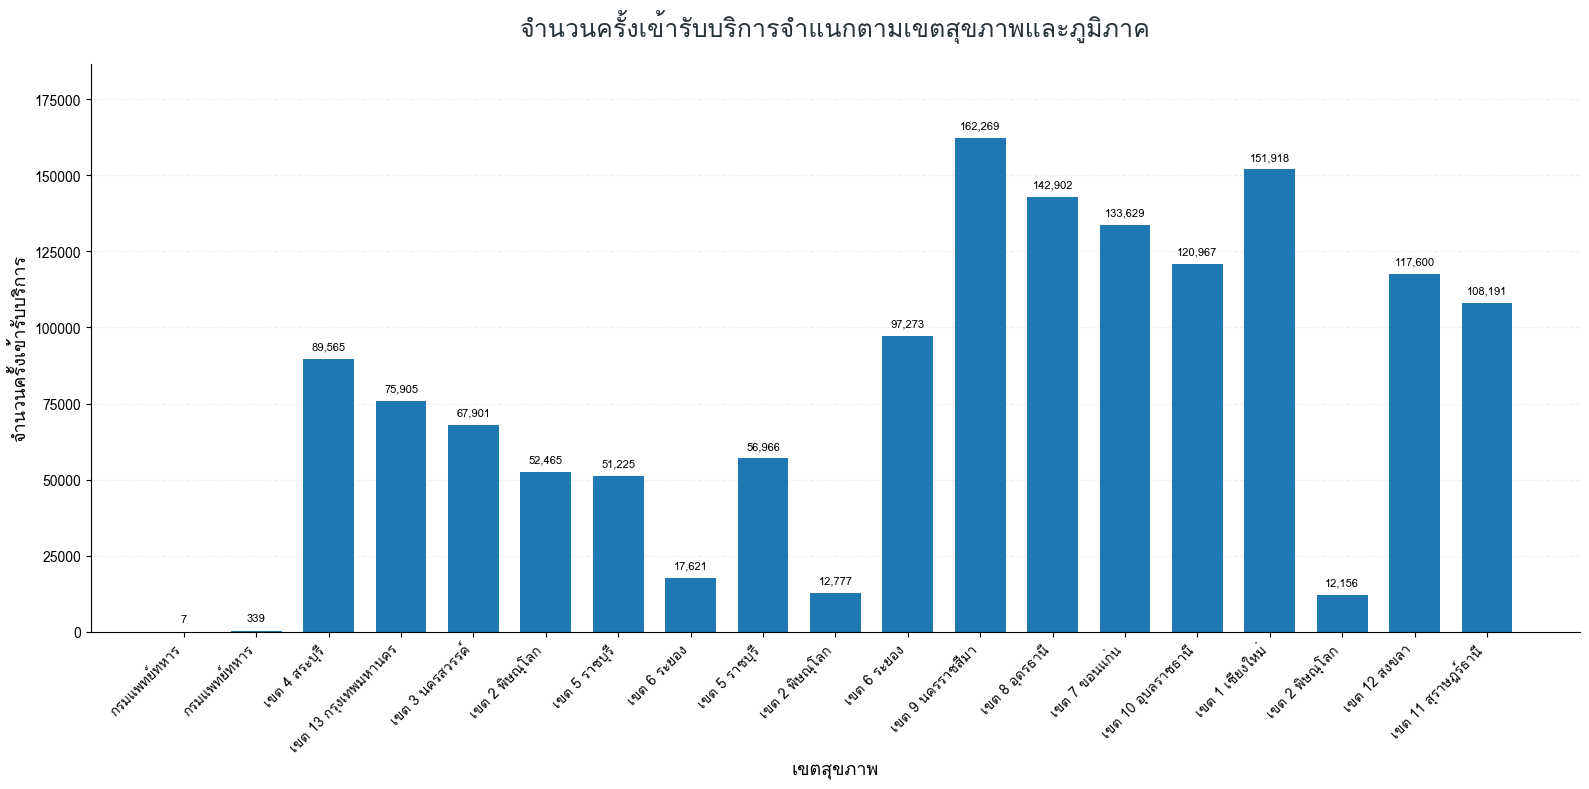

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# รวมจำนวนครั้งเข้ารับบริการตามภาคและเขตสุขภาพ
# ============================================================

region_zone = (
    data.groupby(["ภาค", "nhso_zonename"])["n_service"]
    .sum()
    .reset_index()
)

# เรียงภาคและจำนวนบริการ
region_zone = region_zone.sort_values(
    ["ภาค", "n_service"],
    ascending=[True, False]
).reset_index(drop=True)


# ============================================================
# สร้างกราฟ
# ============================================================

plt.figure(figsize=(16, 8))

bars = plt.bar(
    range(len(region_zone)),
    region_zone["n_service"],
    width=0.7
)


# ============================================================
# ชื่อกราฟ
# ============================================================

plt.title(
    "จำนวนครั้งเข้ารับบริการจำแนกตามเขตสุขภาพและภูมิภาค",
    fontsize=18,
    fontweight="bold",
    color="#263238",
    pad=20
)

plt.xlabel(
    "เขตสุขภาพ",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "จำนวนครั้งเข้ารับบริการ",
    fontsize=13,
    fontweight="bold"
)


# ============================================================
# ชื่อเขตสุขภาพ
# ============================================================

plt.xticks(
    range(len(region_zone)),
    region_zone["nhso_zonename"],
    rotation=45,
    ha="right",
    fontsize=10
)


# ============================================================
# ใส่ตัวเลขบนแท่ง
# ============================================================

max_value = region_zone["n_service"].max()

for bar, value in zip(
    bars,
    region_zone["n_service"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + max_value * 0.015,   # เพิ่มระยะห่างจากแท่ง
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        rotation=0
    )


# ============================================================
# Grid
# ============================================================

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

plt.gca().set_axisbelow(True)

# เอาเส้นกรอบด้านบนและขวาออก
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


# เพิ่มพื้นที่ด้านบนสำหรับตัวเลข
plt.ylim(
    0,
    max_value * 1.15
)

plt.tight_layout()
plt.show()

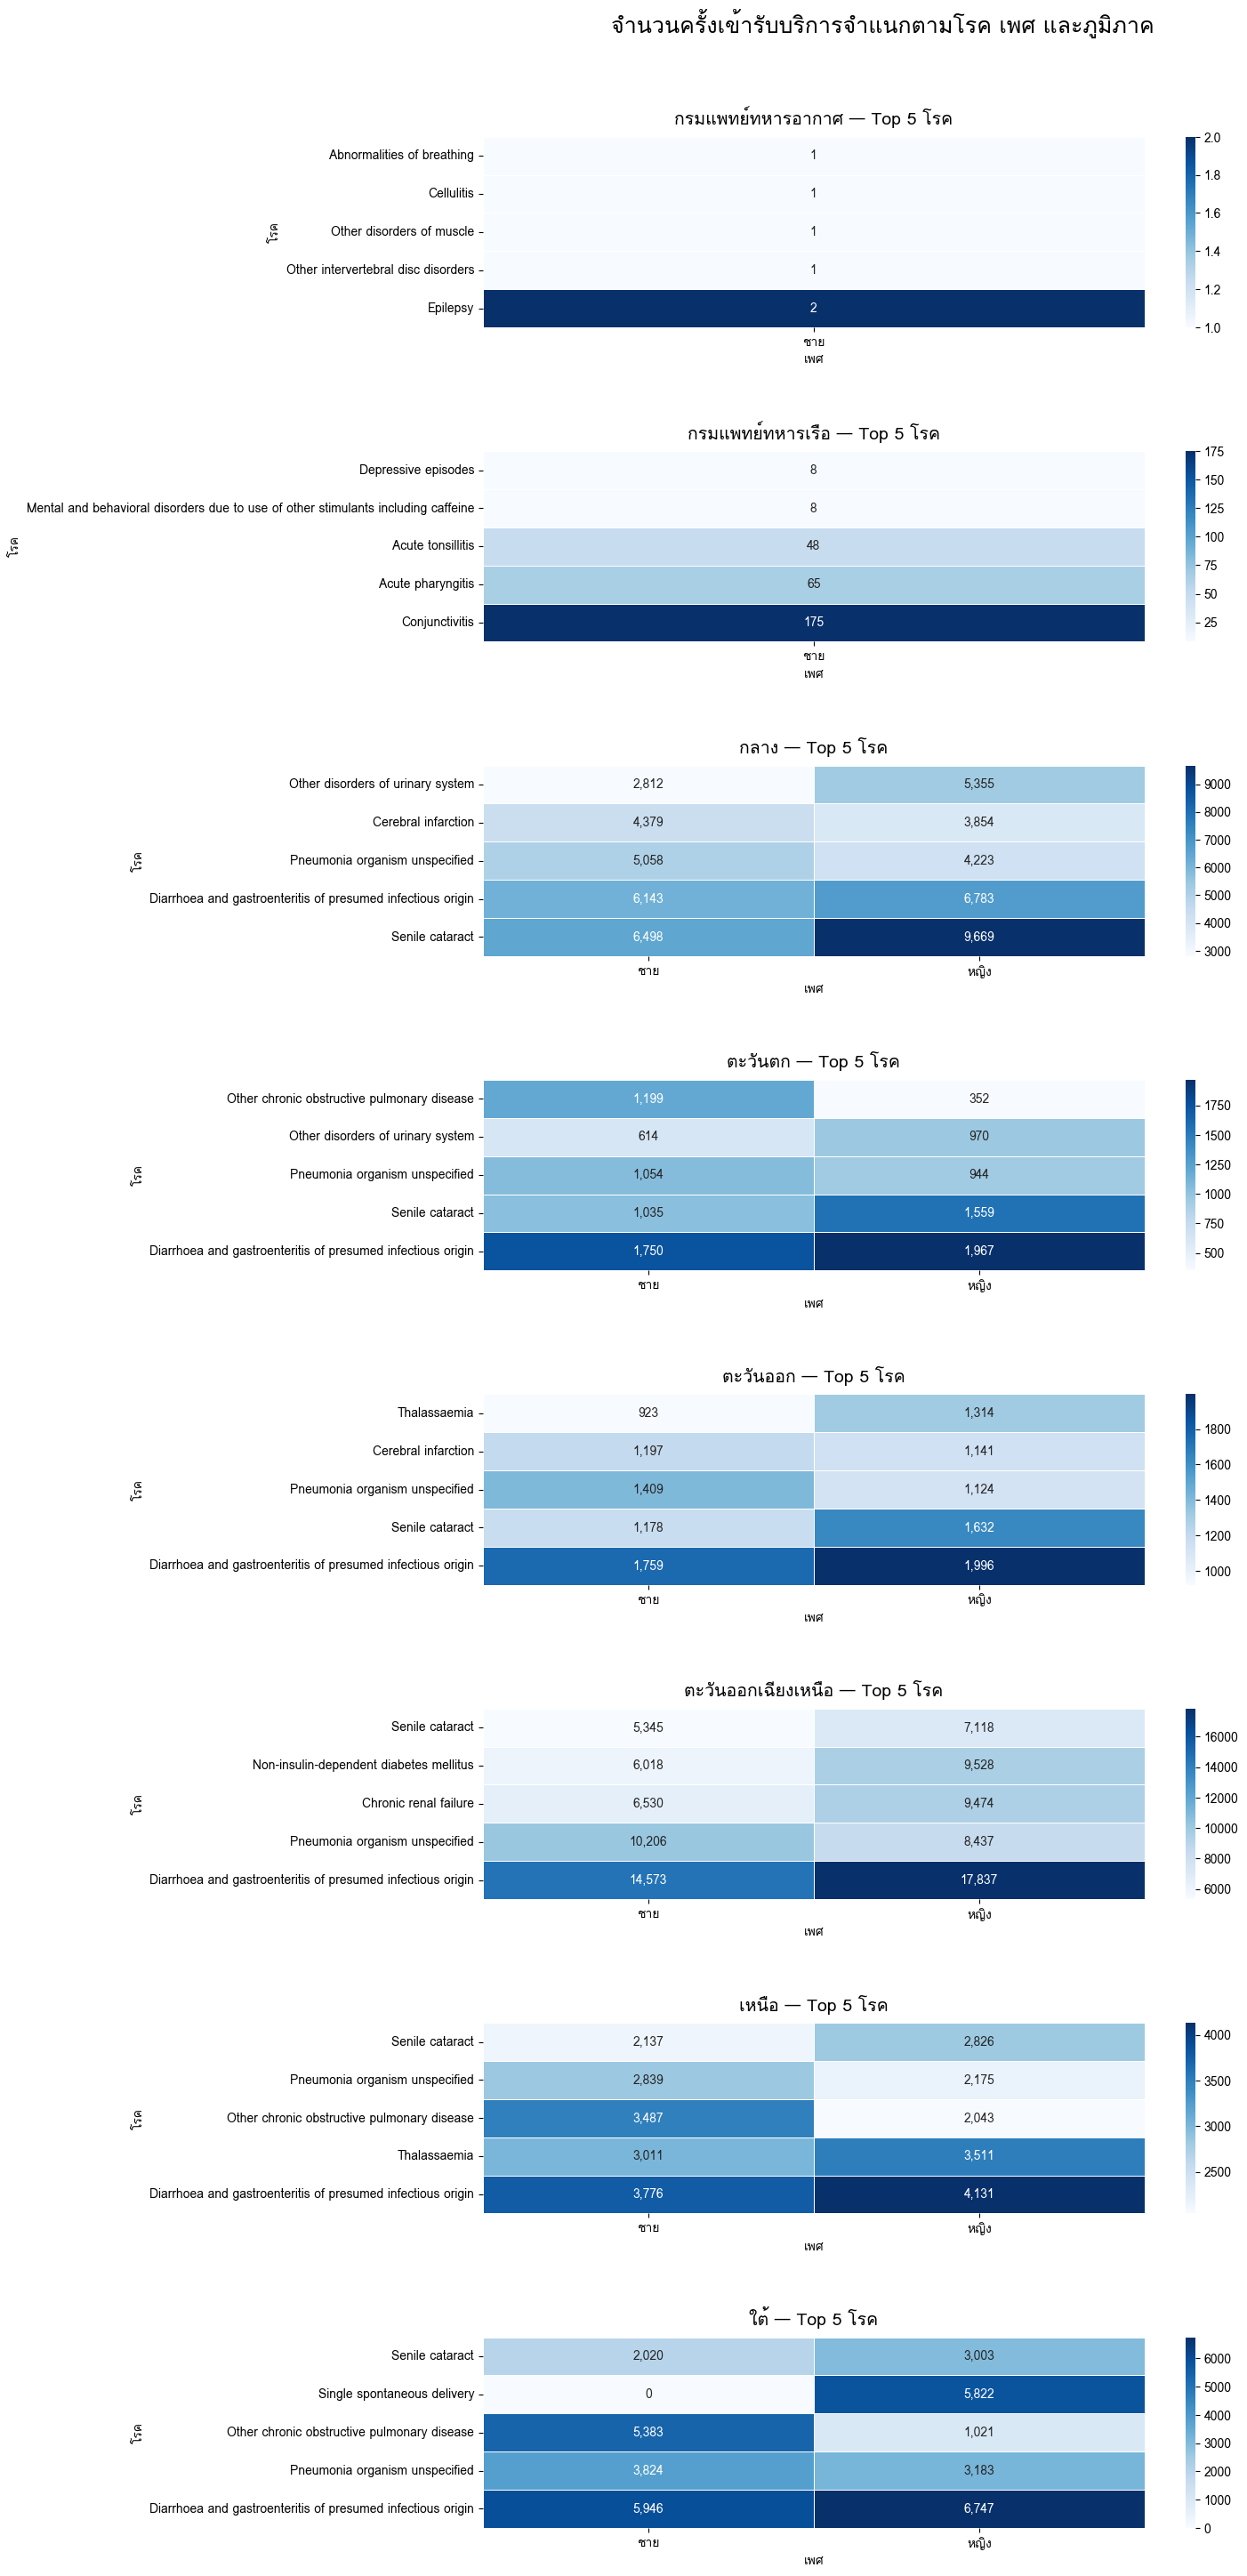

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# แปลงรหัสเพศ
data["gender_label"] = data["gender"].map({
    1: "ชาย",
    2: "หญิง"
}).fillna("ไม่ระบุ")

# รวมจำนวนบริการตามภาค โรค และเพศ
region_disease_gender = (
    data.groupby(["ภาค", "pdx_name", "gender_label"])["n_service"]
    .sum()
    .reset_index()
)

# หา Top 5 โรคของแต่ละภาค
top5_region = (
    region_disease_gender
    .groupby(["ภาค", "pdx_name"])["n_service"]
    .sum()
    .reset_index()
    .sort_values(["ภาค", "n_service"], ascending=[True, False])
    .groupby("ภาค")
    .head(5)
)

# เลือกเฉพาะ Top 5
plot_data = region_disease_gender.merge(
    top5_region[["ภาค", "pdx_name"]],
    on=["ภาค", "pdx_name"]
)

# รายชื่อภาค
regions = plot_data["ภาค"].unique()

# สร้างกราฟ
fig, axes = plt.subplots(
    nrows=len(regions),
    ncols=1,
    figsize=(12, 4 * len(regions))
)

# กรณีมีภาคเดียว
if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):

    temp = plot_data[plot_data["ภาค"] == region]

    pivot = temp.pivot_table(
        index="pdx_name",
        columns="gender_label",
        values="n_service",
        aggfunc="sum",
        fill_value=0
    )

    # เรียงตามจำนวนรวม
    pivot["รวม"] = pivot.sum(axis=1)
    pivot = pivot.sort_values("รวม", ascending=True)
    pivot = pivot.drop(columns="รวม")

    sns.heatmap(
        pivot,
        annot=True,
        fmt=",.0f",
        cmap="Blues",
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(
        f"{region} — Top 5 โรค",
        fontsize=14,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel("เพศ")
    ax.set_ylabel("โรค")

# หัวข้อใหญ่
fig.suptitle(
    "จำนวนครั้งเข้ารับบริการจำแนกตามโรค เพศ และภูมิภาค",
    fontsize=18,
    fontweight="bold",
    y=0.995
)

# เว้นพื้นที่ไม่ให้หัวข้อทับกราฟ
plt.subplots_adjust(
    top=0.95,
    hspace=0.65
)

plt.show()